# 06 Metadata oficial + alineación textual para ground truth proxy

Versión única y corregida v4: BigQuery notebook 00 + parser textual explícito AGENT/CLIENT.

Esta versión **no vuelve a correr el notebook 00 completo**. Solo replica la carga de metadata de BigQuery usada en el notebook 00:

```python
SELECT *
FROM `mm-bi-catedras-upm.AUDIO_DETECTION.tablon_audios`

SELECT *
FROM `mm-bi-catedras-upm.AUDIO_DETECTION.tablon_audios_bajas`
```

La diferencia clave respecto al notebook 00 original es que aquí **sí se conserva la columna `transcripcion`**, porque es necesaria para construir el proxy de rol `AGENT` / `CLIENT` mediante comparación textual contra Whisper.


In [1]:
# =========================
# IMPORTS Y CONFIGURACIÓN
# =========================

import os
import re
import json
import gc
import html
import hashlib
import unicodedata
from pathlib import Path
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, confusion_matrix

try:
    from google.cloud import storage, bigquery
    HAS_GCP = True
except Exception:
    HAS_GCP = False
    storage = None
    bigquery = None

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")
DATA_DIR = PROJECT_DIR / "data"

SEGMENTS_CSV = DATA_DIR / "diarization_outputs" / "consolidated" / "all_final_merged_segments.csv"
WHISPER_CANDIDATES = [
    DATA_DIR / "transcription_outputs" / "06_transcribed_segments_final.csv",
    DATA_DIR / "transcription_outputs" / "all_segments_transcribed.csv",
]
AUDIO_INVENTORY_PRIVATE_CSV = DATA_DIR / "eda" / "audio_inventory_private.csv"
BQ_METADATA_SNAPSHOT_CSV = DATA_DIR / "eda" / "bq_metadata_snapshot.csv"

OUTPUT_DIR = DATA_DIR / "proxy_groundtruth_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
for d in [OUTPUT_DIR, FIGURES_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAVE_OUTPUTS_TO_GCS = True
GCS_OUTPUT_PREFIX = "gs://catedras_audio_detection/pipelineA/procesados_UNAV/proxy_groundtruth_outputs/"

# Parámetros de alineación textual
MAX_WINDOW_SIZE = 4                  # ventanas de 1 a 4 segmentos consecutivos
MAX_GAP_BETWEEN_SEGMENTS_SEC = 1.25  # solo junta segmentos cercanos
MIN_WORDS_OFFICIAL = 4
MIN_WORDS_WHISPER_WINDOW = 4
MIN_TEXT_CHARS = 18

# Umbral recomendado inicial; luego se explora sensibilidad con otros umbrales
ACCEPT_COMBINED_SCORE = 0.70  # criterio recomendado; se explora también 0.80 y 0.90
ACCEPT_CHAR_COSINE = 0.50
ACCEPT_TOKEN_CONTAINMENT = 0.35
ACCEPT_MARGIN = 0.03

# Inferencia speaker -> rol
MIN_MATCHES_FOR_SPEAKER_ROLE = 2
MIN_ROLE_PURITY = 0.70

# Validación estricta de roles oficiales:
# Si la transcripción oficial solo trae AGENT o solo CLIENT, NO se usa para asignar rol.
REQUIRE_BOTH_ROLES_PER_AUDIO = True
REQUIRE_ONE_TO_ONE_AGENT_CLIENT_MAPPING = True
MIN_MATCHES_PER_ROLE_IN_AUDIO = 1

# Evidencia textual agregada por speaker para asignar AGENT / CLIENT
# Esta es la regla principal corregida: no depende de un match aislado,
# sino de varios segmentos limpios por hablante.
ROLE_ASSIGNMENT_MODE = "aggregated_speaker_text"
ROLE_EVIDENCE_MAX_SEGMENTS_PER_SPEAKER = 10
ROLE_EVIDENCE_TARGET_SECONDS_PER_SPEAKER = 25.0
ROLE_EVIDENCE_MIN_SECONDS_PER_SPEAKER = 8.0
ROLE_EVIDENCE_MIN_SEGMENTS_PER_SPEAKER = 2
ROLE_EVIDENCE_MIN_WORDS_PER_SPEAKER = 6
ROLE_EVIDENCE_MAX_OVERLAP_RATIO_STRICT = 0.05
ROLE_EVIDENCE_MIN_WORDS_PER_SEGMENT = 2
MIN_AGGREGATED_PAIR_MARGIN = 0.01
MIN_AGGREGATED_PAIR_SCORE = 0.10

# Para pruebas rápidas: pon un número, por ejemplo 50. Para correr todo: None
MAX_AUDIOS_TO_PROCESS = None  # prueba rápida: 50; corrida completa: None
SAVE_CHECKPOINT_EVERY_N_AUDIOS = 50

BQ_PROJECT_ID = "mm-bi-catedras-upm"
BQ_DATASET = "AUDIO_DETECTION"
BQ_METADATA_SOURCES = {
    "raw": "tablon_audios",
    "raw_bajas": "tablon_audios_bajas",
}

ANONYMIZATION_SALT = os.environ.get("TFM_ANONYMIZATION_SALT", "tfm_local_salt_not_for_final_release")

print("SEGMENTS_CSV:", SEGMENTS_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GCP disponible:", HAS_GCP)

SEGMENTS_CSV: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/consolidated/all_final_merged_segments.csv
OUTPUT_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs
GCP disponible: True


In [2]:
# =========================
# HELPERS GENERALES + GCS
# =========================

def hash_value(value, salt=ANONYMIZATION_SALT):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == "" or value.lower() in {"nan", "none", "null"}:
        return np.nan
    return hashlib.sha256(f"{salt}_{value}".encode("utf-8")).hexdigest()[:16]


def text_hash(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    if value.strip() == "":
        return np.nan
    return hashlib.sha256(value.encode("utf-8")).hexdigest()[:16]


def normalize_audio_stem(name):
    if pd.isna(name):
        return np.nan
    s = Path(str(name).strip()).name
    s = re.sub(r"\.wav$", "", s, flags=re.I)
    s = re.sub(r"_clean$", "", s, flags=re.I)
    return s


def infer_source_dataset_from_name(name):
    s = normalize_audio_stem(name)
    if pd.isna(s):
        return np.nan
    if str(s).startswith("raw_bajas_"):
        return "raw_bajas"
    if str(s).startswith("raw_"):
        return "raw"
    return np.nan


def strip_source_prefix(stem):
    if pd.isna(stem):
        return np.nan
    s = str(stem).strip()
    if s.startswith("raw_bajas_"):
        return s[len("raw_bajas_"):]
    if s.startswith("raw_"):
        return s[len("raw_"):]
    return s


def make_audio_key_variants(name, source_dataset=None):
    stem = normalize_audio_stem(name)
    if pd.isna(stem):
        return []
    base = strip_source_prefix(stem)
    variants = {stem, base}
    if source_dataset == "raw_bajas":
        variants.add(f"raw_bajas_{base}")
    if source_dataset == "raw":
        variants.add(f"raw_{base}")
    return [v for v in variants if isinstance(v, str) and v.strip()]


def split_gcs_uri(uri):
    path = str(uri)[5:]
    bucket_name, _, prefix = path.partition("/")
    return bucket_name, prefix


def upload_file_to_gcs(local_path, gcs_prefix=GCS_OUTPUT_PREFIX):
    if not SAVE_OUTPUTS_TO_GCS:
        return None
    if not HAS_GCP:
        print("GCP no disponible; no se sube:", local_path)
        return None
    local_path = Path(local_path)
    if not local_path.exists():
        print("No existe:", local_path)
        return None
    try:
        bucket_name, prefix = split_gcs_uri(gcs_prefix)
        blob_path = f"{prefix.rstrip('/')}/{local_path.relative_to(OUTPUT_DIR) if OUTPUT_DIR in local_path.parents else local_path.name}"
        client = storage.Client()
        client.bucket(bucket_name).blob(str(blob_path)).upload_from_filename(str(local_path))
        return f"gs://{bucket_name}/{blob_path}"
    except Exception as e:
        print(f"Error subiendo {local_path.name} a GCS: {e}")
        return None


def count_words(text):
    if pd.isna(text):
        return 0
    return len(re.findall(r"\w+", str(text), flags=re.UNICODE))


def normalize_role(role):
    if pd.isna(role):
        return np.nan
    s = str(role).strip().upper()
    s = re.sub(r"[^A-ZÁÉÍÓÚÑ_ ]", "", s)
    if any(x in s for x in ["AGENTE", "AGENT", "ASESOR", "OPERADOR", "COMERCIAL"]):
        return "AGENT"
    if any(x in s for x in ["CLIENTE", "CUSTOMER", "USUARIO"]):
        return "CLIENT"
    return np.nan


def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", str(s)) if not unicodedata.combining(c))


def normalize_text_for_match(text):
    if pd.isna(text):
        return ""
    s = strip_accents(str(text).lower())
    s = re.sub(r"[^a-z0-9ñáéíóúü\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def tokens_for_match(text):
    s = normalize_text_for_match(text)
    toks = re.findall(r"[a-z0-9ñ]+", s)
    # stopwords muy básicas para que no dominen palabras vacías
    stop = {"de", "la", "el", "y", "que", "en", "a", "un", "una", "los", "las", "por", "para", "con", "no", "si", "se", "lo", "le", "me", "es", "su"}
    return [t for t in toks if t not in stop]


def token_containment(a, b):
    ta, tb = set(tokens_for_match(a)), set(tokens_for_match(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / max(1, min(len(ta), len(tb)))


def token_jaccard(a, b):
    ta, tb = set(tokens_for_match(a)), set(tokens_for_match(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / max(1, len(ta | tb))

## 1. Cargar segmentos finales, Whisper segmentado y metadata oficial

In [3]:
# =========================
# CARGA DE SEGMENTOS + WHISPER
# =========================

if not SEGMENTS_CSV.exists():
    raise FileNotFoundError(f"No existe SEGMENTS_CSV: {SEGMENTS_CSV}")

df_segments = pd.read_csv(SEGMENTS_CSV)
print("Segmentos finales:", df_segments.shape)

required = ["audio_file", "start", "end", "duration", "speaker_final"]
missing = [c for c in required if c not in df_segments.columns]
if missing:
    raise ValueError(f"Faltan columnas necesarias en segmentos: {missing}")

whisper_path = next((p for p in WHISPER_CANDIDATES if p.exists()), None)
if whisper_path is None:
    raise FileNotFoundError(f"No se encontró Whisper segmentado en: {WHISPER_CANDIDATES}")

df_whisper = pd.read_csv(whisper_path)
print("Whisper segmentado:", whisper_path)
print("Whisper:", df_whisper.shape)

text_col = "text" if "text" in df_whisper.columns else "transcription" if "transcription" in df_whisper.columns else None
if text_col is None:
    raise ValueError("No se encontró columna de texto en Whisper: esperaba 'text' o 'transcription'.")

# Aseguramos columnas base y texto limpio
for c in ["audio_file", "start", "end", "speaker_final"]:
    if c not in df_whisper.columns:
        raise ValueError(f"Falta columna en Whisper: {c}")

df_whisper["whisper_text"] = df_whisper[text_col].fillna("").astype(str).str.strip()
df_whisper["whisper_norm"] = df_whisper["whisper_text"].apply(normalize_text_for_match)
df_whisper["whisper_word_count"] = df_whisper["whisper_text"].apply(count_words)

display(df_whisper[["audio_file", "start", "end", "speaker_final", "whisper_text", "whisper_word_count"]].head())

Segmentos finales: (40352, 26)
Whisper segmentado: /home/jupyter/TFM_ProcesadoDeAudios/data/transcription_outputs/06_transcribed_segments_final.csv
Whisper: (40352, 55)


,audio_file,start,end,speaker_final,whisper_text,whisper_word_count
0,raw_9154117451310006851_clean.wav,0.030969,4.452219,SPEAKER_01,"Hola, buenos días. Pregunto por Luis Ángel. So...",14
1,raw_9154117451310006851_clean.wav,5.211594,6.342219,SPEAKER_00,"Sí, cuéntame.",2
2,raw_9154117451310006851_clean.wav,6.426594,13.800969,SPEAKER_01,"Hola Luis, me encanta saludarte. El motivo de ...",28
3,raw_9154117451310006851_clean.wav,13.800969,14.965344,SPEAKER_00,¿Te,1
4,raw_9154117451310006851_clean.wav,15.285969,19.994094,SPEAKER_01,han llamado los técnicos de plantas terna o al...,13


In [4]:
# =========================
# CARGA DE METADATA OFICIAL DESDE BIGQUERY
# MISMA FUENTE DEL NOTEBOOK 00, CONSERVANDO transcripcion
# =========================

def _normalize_str_col(s):
    return (
        s.astype("string")
         .fillna("")
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
    )


def load_metadata_exactly_as_notebook00():
    """
    Replica la carga de metadata del notebook 00:
        SELECT * FROM tablon_audios
        SELECT * FROM tablon_audios_bajas

    El notebook 00 comprobaba que BigQuery traía la columna 'transcripcion',
    pero luego la descartaba al seleccionar columnas para el inventario.
    Aquí la conservamos.
    """
    if not HAS_GCP:
        raise RuntimeError("No está disponible google-cloud-bigquery para cargar metadata desde BigQuery.")

    bq_client = bigquery.Client(project=BQ_PROJECT_ID)
    frames = []

    for source_dataset, table_name in BQ_METADATA_SOURCES.items():
        print(f"Cargando BigQuery notebook 00: {source_dataset} | {table_name}")
        bq_sql = f"""
        SELECT *
        FROM `{BQ_PROJECT_ID}.{BQ_DATASET}.{table_name}`
        """
        df_tmp = bq_client.query(bq_sql).to_dataframe()
        df_tmp["source_dataset"] = source_dataset
        df_tmp["bq_table"] = table_name
        frames.append(df_tmp)

    df_metadata_original = pd.concat(frames, ignore_index=True)

    print("\nMetadata cargada como notebook 00.")
    print("Dimensiones:", df_metadata_original.shape)
    print("Fuentes:")
    print(df_metadata_original["source_dataset"].value_counts(dropna=False))
    print("Columnas:")
    print(df_metadata_original.columns.tolist())

    if "transcripcion" not in df_metadata_original.columns:
        raise ValueError(
            "BigQuery no devolvió columna 'transcripcion'. "
            "Revisa si cambió el esquema de las tablas."
        )

    # Normalización mínima, manteniendo transcripcion.
    df_meta = df_metadata_original.copy()

    # Asegurar columnas esperadas aunque alguna tabla no tenga todas.
    for c in [
        "filename", "customer_id", "agent_id", "brand_ds", "duration_min",
        "transcripcion", "url", "tipo_llamada", "mono_stereo", "baja_total_30_dias",
        "source_dataset", "bq_table"
    ]:
        if c not in df_meta.columns:
            df_meta[c] = pd.NA

    for c in ["source_dataset", "bq_table", "filename", "customer_id", "agent_id", "brand_ds"]:
        df_meta[c] = _normalize_str_col(df_meta[c])

    # Este audio_id replica la lógica del notebook 00: parte del filename.
    # Además quitamos .wav/_clean por seguridad, aunque en BigQuery normalmente viene sin extensión.
    df_meta["audio_id"] = df_meta["filename"].apply(normalize_audio_stem).astype("string").str.strip()
    df_meta["audio_id_base"] = df_meta["audio_id"].apply(strip_source_prefix).astype("string").str.strip()

    # Hashes iguales a notebook 00.
    df_meta["audio_hash"] = df_meta["filename"].apply(hash_value)
    df_meta["customer_hash"] = df_meta["customer_id"].apply(hash_value)
    df_meta["agent_hash"] = df_meta["agent_id"].apply(hash_value)

    df_meta["has_official_transcription"] = (
        df_meta["transcripcion"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    print("\nResumen transcripción oficial:")
    print("Audios metadata:", df_meta["audio_id_base"].nunique())
    print("Filas con transcripcion:", int(df_meta["has_official_transcription"].sum()))
    print("Filas sin transcripcion:", int((~df_meta["has_official_transcription"]).sum()))

    # Guardado local de snapshot específico de este notebook, para trazabilidad.
    # No se sube automáticamente porque contiene transcripción oficial y IDs privados.
    bq_snapshot_exact_path = OUTPUT_DIR / "bq_metadata_notebook00_exact_with_transcripcion.csv"
    snapshot_cols = [
        "source_dataset", "bq_table", "filename", "audio_id", "audio_id_base",
        "customer_id", "agent_id", "brand_ds", "duration_min", "transcripcion",
        "url", "tipo_llamada", "mono_stereo", "baja_total_30_dias",
        "audio_hash", "customer_hash", "agent_hash", "has_official_transcription"
    ]
    snapshot_cols = [c for c in snapshot_cols if c in df_meta.columns]
    df_meta[snapshot_cols].to_csv(bq_snapshot_exact_path, index=False)
    print("Snapshot local BigQuery exacto guardado en:", bq_snapshot_exact_path)

    return df_meta


df_meta = load_metadata_exactly_as_notebook00()
metadata_source = "bigquery_live_same_query_as_notebook00"

print("\nFuente metadata:", metadata_source)
print("Metadata final:", df_meta.shape)

display(
    df_meta[
        ["source_dataset", "bq_table", "filename", "audio_id", "customer_id",
         "agent_id", "brand_ds", "duration_min", "has_official_transcription"]
    ].head()
)


Cargando BigQuery notebook 00: raw | tablon_audios
Cargando BigQuery notebook 00: raw_bajas | tablon_audios_bajas

Metadata cargada como notebook 00.
Dimensiones: (1199, 12)
Fuentes:
source_dataset
raw_bajas    1000
raw           199
Name: count, dtype: int64
Columnas:
['filename', 'customer_id', 'agent_id', 'brand_ds', 'duration_min', 'transcripcion', 'url', 'source_dataset', 'bq_table', 'tipo_llamada', 'mono_stereo', 'baja_total_30_dias']

Resumen transcripción oficial:
Audios metadata: 1199
Filas con transcripcion: 1197
Filas sin transcripcion: 2
Snapshot local BigQuery exacto guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/bq_metadata_notebook00_exact_with_transcripcion.csv

Fuente metadata: bigquery_live_same_query_as_notebook00
Metadata final: (1199, 18)


,source_dataset,bq_table,filename,audio_id,customer_id,agent_id,brand_ds,duration_min,has_official_transcription
0,raw,tablon_audios,9156198475400026851,9156198475400026851,10618464,,,NaN,False
1,raw,tablon_audios,9156337044000006851,9156337044000006851,11444283,,,NaN,False
2,raw,tablon_audios,9156458509420006851,9156458509420006851,112056,111922008,EUSKALTEL,2.68,True
3,raw,tablon_audios,9156458226960006851,9156458226960006851,112056,111211113,EUSKALTEL,3.13,True
4,raw,tablon_audios,9156131897590006851,9156131897590006851,11054896,2521216,GUUK,3.87,True


In [5]:
# =========================
# MATCH ROBUSTO AUDIO DIARIZADO / WHISPER ↔ METADATA BIGQUERY
# =========================

# Base: audios presentes en la diarización final.
seg_audio = df_segments[["audio_file"]].drop_duplicates().copy()

# Si el consolidado trae source_dataset, lo usamos; si no, se infiere del nombre.
if "source_dataset" in df_segments.columns:
    seg_source = (
        df_segments[["audio_file", "source_dataset"]]
        .drop_duplicates("audio_file")
        .rename(columns={"source_dataset": "segment_source_dataset"})
    )
    seg_audio = seg_audio.merge(seg_source, on="audio_file", how="left")
else:
    seg_audio["segment_source_dataset"] = seg_audio["audio_file"].apply(infer_source_dataset_from_name)

seg_audio["segment_stem"] = seg_audio["audio_file"].apply(normalize_audio_stem).astype("string").str.strip()
seg_audio["segment_audio_id_base"] = seg_audio["segment_stem"].apply(strip_source_prefix).astype("string").str.strip()

seg_counts = (
    df_segments.groupby("audio_file")
    .agg(
        n_diarized_segments=("audio_file", "size"),
        diarized_duration_sec=("duration", "sum"),
        n_speakers=("speaker_final", "nunique"),
        first_start=("start", "min"),
        last_end=("end", "max"),
    )
    .reset_index()
)
seg_audio = seg_audio.merge(seg_counts, on="audio_file", how="left")
seg_audio["diarized_duration_min"] = seg_audio["diarized_duration_sec"] / 60

# Metadata BigQuery normalizada.
meta_lookup = df_meta.copy()
meta_lookup["source_dataset"] = _normalize_str_col(meta_lookup["source_dataset"])
meta_lookup["audio_id_base"] = _normalize_str_col(meta_lookup["audio_id_base"])

# Columnas de metadata que queremos conservar.
meta_cols = [
    "source_dataset", "bq_table", "filename", "audio_id", "audio_id_base",
    "audio_hash", "customer_hash", "agent_hash", "customer_id", "agent_id",
    "brand_ds", "duration_min", "transcripcion", "url",
    "tipo_llamada", "mono_stereo", "baja_total_30_dias",
    "has_official_transcription"
]
meta_cols = [c for c in meta_cols if c in meta_lookup.columns]

# 1) Match estricto por source_dataset + audio_id, cuando source_dataset existe.
seg_with_source = seg_audio[
    seg_audio["segment_source_dataset"].notna()
    & seg_audio["segment_source_dataset"].astype(str).str.strip().ne("")
    & ~seg_audio["segment_source_dataset"].astype(str).str.lower().isin(["nan", "none", "unknown"])
].copy()

match_source = seg_with_source.merge(
    meta_lookup[meta_cols],
    left_on=["segment_source_dataset", "segment_audio_id_base"],
    right_on=["source_dataset", "audio_id_base"],
    how="left"
)
match_source = match_source[match_source["filename"].notna()].copy()
match_source["match_method"] = "source_dataset_plus_audio_id"

matched_audio_files = set(match_source["audio_file"].dropna().unique())

# 2) Fallback por audio_id único en BigQuery.
remaining = seg_audio[~seg_audio["audio_file"].isin(matched_audio_files)].copy()

meta_unique = (
    meta_lookup
    .groupby("audio_id_base")
    .filter(lambda x: x[["source_dataset", "filename"]].drop_duplicates().shape[0] == 1)
    .copy()
)

match_unique = remaining.merge(
    meta_unique[meta_cols],
    left_on="segment_audio_id_base",
    right_on="audio_id_base",
    how="left"
)
match_unique = match_unique[match_unique["filename"].notna()].copy()
match_unique["match_method"] = "audio_id_unique_fallback"

matched_audio_files.update(match_unique["audio_file"].dropna().unique())

# 3) Fallback por audio_id duplicado, eligiendo duración más cercana si existe.
remaining = seg_audio[~seg_audio["audio_file"].isin(matched_audio_files)].copy()

meta_dupes = (
    meta_lookup
    .groupby("audio_id_base")
    .filter(lambda x: x[["source_dataset", "filename"]].drop_duplicates().shape[0] > 1)
    .copy()
)

match_duration = remaining.merge(
    meta_dupes[meta_cols],
    left_on="segment_audio_id_base",
    right_on="audio_id_base",
    how="left"
)
match_duration = match_duration[match_duration["filename"].notna()].copy()

if len(match_duration):
    match_duration["duration_min_num"] = pd.to_numeric(match_duration.get("duration_min"), errors="coerce")
    match_duration["duration_diff_abs"] = (
        match_duration["diarized_duration_min"] - match_duration["duration_min_num"]
    ).abs()
    match_duration = (
        match_duration
        .sort_values(["audio_file", "duration_diff_abs"], na_position="last")
        .drop_duplicates("audio_file", keep="first")
        .copy()
    )
    match_duration["match_method"] = "audio_id_duplicate_duration_fallback"

# Consolidar matches.
matches = pd.concat([match_source, match_unique, match_duration], ignore_index=True, sort=False)

method_rank = {
    "source_dataset_plus_audio_id": 1,
    "audio_id_unique_fallback": 2,
    "audio_id_duplicate_duration_fallback": 3,
}
if len(matches):
    matches["method_rank"] = matches["match_method"].map(method_rank).fillna(99)
    matches = (
        matches
        .sort_values(["audio_file", "method_rank"])
        .drop_duplicates("audio_file", keep="first")
        .copy()
    )

# Auditoría final: una fila por audio diarizado.
match_cols = ["audio_file", "match_method"] + meta_cols
match_cols = [c for c in match_cols if c in matches.columns]

seg_match_audit = seg_audio.merge(
    matches[match_cols] if len(matches) else pd.DataFrame(columns=match_cols),
    on="audio_file",
    how="left"
)

seg_match_audit["metadata_matched"] = seg_match_audit["match_method"].notna()
seg_match_audit["has_official_transcription"] = (
    seg_match_audit.get("has_official_transcription", pd.Series(False, index=seg_match_audit.index))
    .fillna(False)
    .astype(bool)
)

print("Audios diarizados:", seg_audio["audio_file"].nunique())
print("Audios con metadata BigQuery notebook 00:", int(seg_match_audit["metadata_matched"].sum()))
print("Audios sin metadata:", int((~seg_match_audit["metadata_matched"]).sum()))
print("Audios con transcripción oficial unida:", int(seg_match_audit["has_official_transcription"].sum()))
print("\nMétodo de match:")
print(seg_match_audit["match_method"].value_counts(dropna=False))

display(
    seg_match_audit[
        [
            "audio_file", "segment_audio_id_base", "segment_source_dataset",
            "source_dataset", "filename", "match_method",
            "has_official_transcription", "n_diarized_segments", "n_speakers"
        ]
    ].head(20)
)

if (~seg_match_audit["metadata_matched"]).any():
    print("\nEjemplos sin metadata en BigQuery notebook 00:")
    display(
        seg_match_audit.loc[
            ~seg_match_audit["metadata_matched"],
            ["audio_file", "segment_audio_id_base", "segment_source_dataset", "n_diarized_segments"]
        ].head(30)
    )

# Control de seguridad: si el match es muy bajo, paramos antes de generar métricas engañosas.
coverage = seg_match_audit["metadata_matched"].mean()
if coverage < 0.50:
    print("\nADVERTENCIA: cobertura de metadata menor al 50%.")
    print("Esto normalmente indica que los outputs de Whisper/diarización pertenecen a un universo distinto al BigQuery live del notebook 00.")
    print("El notebook puede seguir, pero los resultados de proxy solo cubrirán los audios cruzados.")


Audios diarizados: 1181
Audios con metadata BigQuery notebook 00: 1181
Audios sin metadata: 0
Audios con transcripción oficial unida: 1179

Método de match:
match_method
source_dataset_plus_audio_id    1181
Name: count, dtype: int64


,audio_file,segment_audio_id_base,segment_source_dataset,source_dataset,filename,match_method,has_official_transcription,n_diarized_segments,n_speakers
0,raw_9154117451310006851_clean.wav,9154117451310006851,raw,raw,9154117451310006851,source_dataset_plus_audio_id,True,37,2
1,raw_9154117551220006851_clean.wav,9154117551220006851,raw,raw,9154117551220006851,source_dataset_plus_audio_id,True,41,2
2,raw_9154127337680006851_clean.wav,9154127337680006851,raw,raw,9154127337680006851,source_dataset_plus_audio_id,True,27,2
3,raw_9154142438160016851_clean.wav,9154142438160016851,raw,raw,9154142438160016851,source_dataset_plus_audio_id,True,46,2
4,raw_9154152155960016851_clean.wav,9154152155960016851,raw,raw,9154152155960016851,source_dataset_plus_audio_id,True,38,2
5,raw_9154188548830006851_clean.wav,9154188548830006851,raw,raw,9154188548830006851,source_dataset_plus_audio_id,True,23,2
6,raw_9154202560160006851_clean.wav,9154202560160006851,raw,raw,9154202560160006851,source_dataset_plus_audio_id,True,19,2
7,raw_9154202749900006851_clean.wav,9154202749900006851,raw,raw,9154202749900006851,source_dataset_plus_audio_id,True,30,2
8,raw_9154219744450006851_clean.wav,9154219744450006851,raw,raw,9154219744450006851,source_dataset_plus_audio_id,True,43,2
9,raw_9154222339820016851_clean.wav,9154222339820016851,raw,raw,9154222339820016851,source_dataset_plus_audio_id,True,50,2


## 2. Extraer turnos oficiales con roles

In [6]:
# =========================
# EXTRACCIÓN DE TURNOS OFICIALES CON ROLES EXPLÍCITOS
# =========================

# Corrección importante:
# La versión anterior estaba leyendo campos internos tipo speaker/role de JSON,
# y en estos datos esos campos pueden venir como AGENT aunque el texto sea del cliente.
# Por eso ahora SOLO se aceptan roles que aparezcan explícitamente en el texto:
# AGENT:, AGENTE:, CLIENT:, CLIENTE:, CUSTOMER:, USUARIO:, etc.
# Además se permite que un turno ocupe varias líneas hasta encontrar el siguiente prefijo.

ROLE_PREFIX_RE = re.compile(
    r"^\s*(?P<role>AGENT|AGENTE|ASESOR|ASESORA|OPERADOR|OPERADORA|COMERCIAL|CLIENT|CLIENTE|CUSTOMER|USUARIO|USUARIA)\s*[#\d_\-\. ]*\s*[:\-]\s*(?P<text>.*)$",
    flags=re.IGNORECASE,
)


def normalize_role_strict(role):
    if role is None or pd.isna(role):
        return np.nan
    r = strip_accents(str(role).strip().upper())
    r = re.sub(r"[^A-ZÑ]", "", r)

    if r in {"AGENT", "AGENTE", "ASESOR", "ASESORA", "OPERADOR", "OPERADORA", "COMERCIAL"}:
        return "AGENT"
    if r in {"CLIENT", "CLIENTE", "CUSTOMER", "USUARIO", "USUARIA"}:
        return "CLIENT"
    return np.nan


def parse_official_turns_role_prefixed(text):
    """
    Extrae turnos oficiales únicamente cuando hay prefijo textual explícito.
    Ejemplo:
        AGENT: hola...
        CLIENT: sí...
    Si una línea no tiene prefijo, se concatena al turno anterior.
    """
    if pd.isna(text) or str(text).strip() == "":
        return []

    raw = str(text).replace("\r\n", "\n").replace("\r", "\n")
    lines = [ln.strip() for ln in raw.split("\n") if ln.strip()]

    turns = []
    current = None

    for line in lines:
        m = ROLE_PREFIX_RE.match(line)

        if m:
            if current is not None and str(current.get("official_text", "")).strip():
                turns.append(current)

            role = normalize_role_strict(m.group("role"))
            current = {
                "official_role_raw": m.group("role"),
                "official_role": role,
                "official_role_source": "explicit_text_prefix",
                "official_text": m.group("text").strip(),
                "official_start": None,
                "official_end": None,
            }
        else:
            # Continuación del turno anterior.
            if current is not None:
                current["official_text"] = (str(current.get("official_text", "")).strip() + " " + line).strip()

    if current is not None and str(current.get("official_text", "")).strip():
        turns.append(current)

    # Limpieza final + numeración
    cleaned = []
    for t in turns:
        role = t.get("official_role")
        txt = str(t.get("official_text", "")).strip()

        if role not in {"AGENT", "CLIENT"}:
            continue

        norm = normalize_text_for_match(txt)
        wc = count_words(txt)

        if wc < MIN_WORDS_OFFICIAL or len(norm) < MIN_TEXT_CHARS:
            continue

        cleaned.append({
            "official_turn_idx": len(cleaned),
            "official_role_raw": t.get("official_role_raw"),
            "official_role": role,
            "official_role_source": t.get("official_role_source"),
            "official_start": t.get("official_start"),
            "official_end": t.get("official_end"),
            "official_text": txt,
            "official_norm": norm,
            "official_word_count": wc,
            "official_text_hash": text_hash(txt),
        })

    return cleaned


turn_rows = []

if "transcripcion" not in seg_match_audit.columns:
    raise ValueError("seg_match_audit no tiene columna 'transcripcion'. Revisa la celda de match metadata ↔ audios.")

for _, r in seg_match_audit[seg_match_audit["metadata_matched"]].iterrows():
    turns = parse_official_turns_role_prefixed(r.get("transcripcion", np.nan))

    for t in turns:
        turn_rows.append({
            "audio_file": r["audio_file"],
            "source_dataset": r.get("source_dataset", pd.NA),
            "audio_id": r.get("audio_id", pd.NA),
            "filename": r.get("filename", pd.NA),
            "customer_hash": r.get("customer_hash", pd.NA),
            "agent_hash": r.get("agent_hash", pd.NA),
            **t,
        })

df_official_turns_all = pd.DataFrame(turn_rows)

if len(df_official_turns_all) == 0:
    raise RuntimeError(
        "No se extrajeron turnos oficiales AGENT/CLIENT con prefijo textual explícito. "
        "Revisa ejemplos de la columna 'transcripcion'."
    )

# Diagnóstico de roles por audio ANTES de usarlo como proxy
role_counts_all = (
    df_official_turns_all
    .groupby(["audio_file", "official_role"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for c in ["AGENT", "CLIENT"]:
    if c not in role_counts_all.columns:
        role_counts_all[c] = 0

role_counts_all["has_both_roles"] = role_counts_all["AGENT"].gt(0) & role_counts_all["CLIENT"].gt(0)

eligible_audio_for_role_proxy = set(
    role_counts_all.loc[role_counts_all["has_both_roles"], "audio_file"]
)

if REQUIRE_BOTH_ROLES_PER_AUDIO:
    df_official_turns = df_official_turns_all[
        df_official_turns_all["audio_file"].isin(eligible_audio_for_role_proxy)
    ].copy()
else:
    df_official_turns = df_official_turns_all.copy()

print("Turnos oficiales extraídos con rol explícito:", df_official_turns_all.shape)
print(df_official_turns_all["official_role"].value_counts(dropna=False))
print("Audios con algún rol explícito:", df_official_turns_all["audio_file"].nunique())
print("Audios con AGENT y CLIENT:", len(eligible_audio_for_role_proxy))
print("Turnos oficiales usados para proxy textual estricto:", df_official_turns.shape)
print(df_official_turns["official_role"].value_counts(dropna=False))

print("\nEjemplos de audios excluidos por tener un solo rol reconocido:")
excluded_role_audio = role_counts_all[~role_counts_all["has_both_roles"]].head(10)
display(excluded_role_audio)

print("\nEjemplos usados para alineación textual:")
display(
    df_official_turns[
        ["audio_file", "official_turn_idx", "official_role", "official_role_source", "official_text", "official_word_count"]
    ].head(20)
)


Turnos oficiales extraídos con rol explícito: (37747, 16)
official_role
AGENT     22701
CLIENT    15046
Name: count, dtype: int64
Audios con algún rol explícito: 1176
Audios con AGENT y CLIENT: 1167
Turnos oficiales usados para proxy textual estricto: (37550, 16)
official_role
AGENT     22543
CLIENT    15007
Name: count, dtype: int64

Ejemplos de audios excluidos por tener un solo rol reconocido:


official_role,audio_file,AGENT,CLIENT,has_both_roles
2,raw_9154127337680006851_clean.wav,5,0,False
3,raw_9154142438160016851_clean.wav,21,0,False
11,raw_9154291167650006851_clean.wav,26,0,False
14,raw_9154340242110006851_clean.wav,14,0,False
18,raw_9154377635160016851_clean.wav,39,0,False
191,raw_bajas_9155998760150016851_clean.wav,0,22,False
207,raw_bajas_9156009499890006851_clean.wav,26,0,False
371,raw_bajas_9156363042950016851_clean.wav,27,0,False
835,raw_bajas_9157149702950016851_clean.wav,0,17,False



Ejemplos usados para alineación textual:


,audio_file,official_turn_idx,official_role,official_role_source,official_text,official_word_count
0,raw_9154117451310006851_clean.wav,0,AGENT,explicit_text_prefix,"Hola, buenos días, pregunto por Luis Ángel, so...",14
1,raw_9154117451310006851_clean.wav,1,AGENT,explicit_text_prefix,"Hola Luis, nada de saludarte, el motivo de mi ...",27
2,raw_9154117451310006851_clean.wav,2,AGENT,explicit_text_prefix,¿Se han llamado los técnicos de plantas?,7
3,raw_9154117451310006851_clean.wav,3,AGENT,explicit_text_prefix,¿Te han dado algo o no tienes noticias?,8
4,raw_9154117451310006851_clean.wav,4,AGENT,explicit_text_prefix,"O sea, ahora tenemos internet.",5
5,raw_9154117451310006851_clean.wav,5,CLIENT,explicit_text_prefix,"Verde y viernes por la tarde, más o menos.",9
6,raw_9154117451310006851_clean.wav,6,AGENT,explicit_text_prefix,Pues es que no nos habían dicho nada.,8
7,raw_9154117451310006851_clean.wav,7,AGENT,explicit_text_prefix,"Es el tamailloso, ¿no?,",4
8,raw_9154117451310006851_clean.wav,8,AGENT,explicit_text_prefix,donde tenías la incidencia.,4
9,raw_9154117451310006851_clean.wav,9,CLIENT,explicit_text_prefix,"O sea, vamos, yo he estado trabajando y bien.",9


## 3. Diagnóstico compacto de metadata y roles oficiales

Se conserva solo el diagnóstico necesario del 06B anterior: cuántos audios tienen metadata, cuántos tienen transcripción oficial utilizable y si realmente aparecen roles `AGENT` y `CLIENT`. La alineación por orden ya no se usa como método principal.

,metric,value
0,audios_diarized,1181
1,segments_diarized,40352
2,audios_with_metadata,1181
3,audios_with_any_official_role_recognized,1176
4,audios_with_both_agent_client_roles,1167
5,official_turns_with_any_role_recognized,37747
6,official_turns_used_for_strict_textual_proxy,37550
7,official_agent_turns_used,22543
8,official_client_turns_used,15007


,audio_file,n_official_turns_recognized,n_agent_turns,n_client_turns,official_words_total,has_agent,has_client,has_both_roles,usable_for_textual_role_proxy
204,raw_bajas_9156001695810016851_clean.wav,72,37,35,977,True,True,True,True
1113,raw_bajas_9157391377820016851_clean.wav,71,61,10,799,True,True,True,True
320,raw_bajas_9156278771380006851_clean.wav,68,47,21,982,True,True,True,True
637,raw_bajas_9156820417800006851_clean.wav,67,19,48,757,True,True,True,True
1112,raw_bajas_9157391375210006851_clean.wav,67,38,29,688,True,True,True,True
752,raw_bajas_9157029354360006851_clean.wav,66,35,31,712,True,True,True,True
883,raw_bajas_9157226438610006851_clean.wav,65,18,47,674,True,True,True,True
1081,raw_bajas_9157364498430006851_clean.wav,65,33,32,726,True,True,True,True
814,raw_bajas_9157114357580036851_clean.wav,64,30,34,676,True,True,True,True
838,raw_bajas_9157157391260006851_clean.wav,64,42,22,546,True,True,True,True


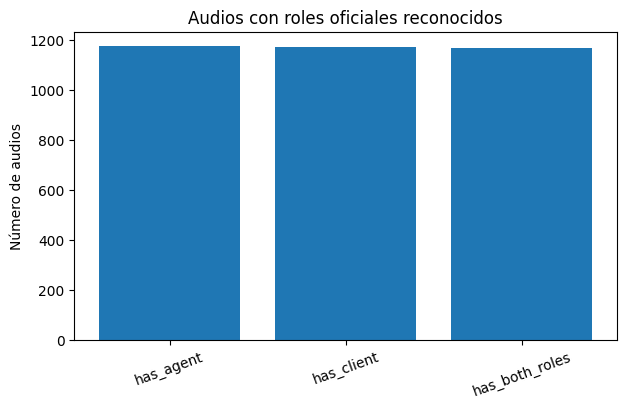

Figura guardada: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/figures/official_role_presence.png


In [7]:
# =========================
# DIAGNÓSTICO COMPACTO DE METADATA + ROLES
# =========================

role_presence_by_audio = pd.DataFrame()
if len(df_official_turns_all):
    role_presence_by_audio = (
        df_official_turns_all
        .assign(has_agent=lambda d: d["official_role"].eq("AGENT"),
                has_client=lambda d: d["official_role"].eq("CLIENT"))
        .groupby("audio_file")
        .agg(
            n_official_turns_recognized=("official_turn_idx", "size"),
            n_agent_turns=("has_agent", "sum"),
            n_client_turns=("has_client", "sum"),
            official_words_total=("official_word_count", "sum"),
        )
        .reset_index()
    )
    role_presence_by_audio["has_agent"] = role_presence_by_audio["n_agent_turns"].gt(0)
    role_presence_by_audio["has_client"] = role_presence_by_audio["n_client_turns"].gt(0)
    role_presence_by_audio["has_both_roles"] = role_presence_by_audio["has_agent"] & role_presence_by_audio["has_client"]
    role_presence_by_audio["usable_for_textual_role_proxy"] = role_presence_by_audio["has_both_roles"]

metadata_role_summary = pd.DataFrame([
    {"metric": "audios_diarized", "value": int(df_segments["audio_file"].nunique())},
    {"metric": "segments_diarized", "value": int(len(df_segments))},
    {"metric": "audios_with_metadata", "value": int(seg_match_audit["metadata_matched"].sum())},
    {"metric": "audios_with_any_official_role_recognized", "value": int(role_presence_by_audio["audio_file"].nunique()) if len(role_presence_by_audio) else 0},
    {"metric": "audios_with_both_agent_client_roles", "value": int(role_presence_by_audio["has_both_roles"].sum()) if len(role_presence_by_audio) else 0},
    {"metric": "official_turns_with_any_role_recognized", "value": int(len(df_official_turns_all)) if 'df_official_turns_all' in globals() else 0},
    {"metric": "official_turns_used_for_strict_textual_proxy", "value": int(len(df_official_turns)) if 'df_official_turns' in globals() else 0},
    {"metric": "official_agent_turns_used", "value": int((df_official_turns["official_role"] == "AGENT").sum()) if len(df_official_turns) else 0},
    {"metric": "official_client_turns_used", "value": int((df_official_turns["official_role"] == "CLIENT").sum()) if len(df_official_turns) else 0},
])

display(metadata_role_summary)
if len(role_presence_by_audio):
    display(role_presence_by_audio.sort_values(["has_both_roles", "n_official_turns_recognized"], ascending=[False, False]).head(15))

if len(role_presence_by_audio):
    fig, ax = plt.subplots(figsize=(7, 4))
    vals = role_presence_by_audio[["has_agent", "has_client", "has_both_roles"]].sum()
    ax.bar(vals.index, vals.values)
    ax.set_title("Audios con roles oficiales reconocidos")
    ax.set_ylabel("Número de audios")
    ax.tick_params(axis="x", rotation=20)
    fig_path = FIGURES_DIR / "official_role_presence.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", fig_path)


## 4. Construir ventanas de Whisper por speaker

Se crean ventanas de 1 a 4 segmentos consecutivos del mismo speaker, siempre que los segmentos estén cerca temporalmente. Esto permite que un turno oficial largo coincida con varios segmentos diarizados unidos.

In [8]:
# =========================
# VENTANAS WHISPER
# =========================

def build_whisper_windows_for_audio(df_audio):
    df_audio = df_audio.sort_values(["start", "end"]).reset_index(drop=True).copy()
    df_audio["segment_order_in_audio"] = np.arange(len(df_audio))
    windows = []

    for i in range(len(df_audio)):
        base = df_audio.iloc[i]
        speaker = base["speaker_final"]
        text_parts = []
        segment_indices = []
        start = float(base["start"])
        last_end = None

        for w in range(1, MAX_WINDOW_SIZE + 1):
            j = i + w - 1
            if j >= len(df_audio):
                break
            row = df_audio.iloc[j]
            if row["speaker_final"] != speaker:
                break
            if last_end is not None and float(row["start"]) - last_end > MAX_GAP_BETWEEN_SEGMENTS_SEC:
                break
            txt = str(row.get("whisper_text", "") or "").strip()
            text_parts.append(txt)
            segment_indices.append(int(row["segment_order_in_audio"]))
            last_end = float(row["end"])

            combined_text = " ".join([t for t in text_parts if t]).strip()
            if count_words(combined_text) < MIN_WORDS_WHISPER_WINDOW:
                continue

            windows.append({
                "audio_file": base["audio_file"],
                "speaker_final": speaker,
                "window_start": start,
                "window_end": last_end,
                "window_size": w,
                "window_first_segment_order": segment_indices[0],
                "window_last_segment_order": segment_indices[-1],
                "window_segment_orders": "|".join(map(str, segment_indices)),
                "whisper_text": combined_text,
                "whisper_norm": normalize_text_for_match(combined_text),
                "whisper_word_count": count_words(combined_text),
            })
    return pd.DataFrame(windows)

# Diagnóstico rápido con un audio
sample_audio = df_whisper["audio_file"].dropna().iloc[0]
sample_windows = build_whisper_windows_for_audio(df_whisper[df_whisper["audio_file"] == sample_audio])
print("Audio muestra:", sample_audio)
print("Ventanas muestra:", sample_windows.shape)
display(sample_windows.head())

Audio muestra: raw_9154117451310006851_clean.wav
Ventanas muestra: (50, 11)


,audio_file,speaker_final,window_start,window_end,window_size,window_first_segment_order,window_last_segment_order,window_segment_orders,whisper_text,whisper_norm,whisper_word_count
0,raw_9154117451310006851_clean.wav,SPEAKER_01,0.030969,4.452219,1,0,0,0,"Hola, buenos días. Pregunto por Luis Ángel. So...",hola buenos dias pregunto por luis angel soy n...,14
1,raw_9154117451310006851_clean.wav,SPEAKER_01,6.426594,13.800969,1,2,2,2,"Hola Luis, me encanta saludarte. El motivo de ...",hola luis me encanta saludarte el motivo de mi...,28
2,raw_9154117451310006851_clean.wav,SPEAKER_01,15.285969,19.994094,1,4,4,4,han llamado los técnicos de plantas terna o al...,han llamado los tecnicos de plantas terna o al...,13
3,raw_9154117451310006851_clean.wav,SPEAKER_00,20.078469,22.187844,1,5,5,5,"O sea, ahora tenemos internet.",o sea ahora tenemos internet,5
4,raw_9154117451310006851_clean.wav,SPEAKER_00,25.967844,29.899719,1,8,8,8,lo he estado reclamándonos. El viernes por la ...,lo he estado reclamandonos el viernes por la t...,12


## 5. Alineación textual oficial ↔ Whisper

Para cada audio, se vectorizan los turnos oficiales y las ventanas Whisper con TF-IDF de caracteres. Además se calculan métricas de solapamiento de palabras. Se aceptan solo matches con score suficiente y margen frente a la segunda mejor opción.

In [9]:
# =========================
# FUNCIÓN DE ALINEACIÓN POR AUDIO
# =========================

def align_one_audio(audio_file, df_turns_audio, df_whisper_audio):
    windows = build_whisper_windows_for_audio(df_whisper_audio)
    if len(df_turns_audio) == 0 or len(windows) == 0:
        return pd.DataFrame()

    official_texts = df_turns_audio["official_norm"].fillna("").astype(str).tolist()
    window_texts = windows["whisper_norm"].fillna("").astype(str).tolist()
    all_texts = official_texts + window_texts

    if len(set([t for t in all_texts if t.strip()])) < 2:
        return pd.DataFrame()

    try:
        vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
        X = vectorizer.fit_transform(all_texts)
        X_off = X[:len(official_texts)]
        X_win = X[len(official_texts):]
        sim = linear_kernel(X_off, X_win)
    except Exception as e:
        print("Error vectorizando", audio_file, e)
        return pd.DataFrame()

    candidates = []
    for oi, (_, turn) in enumerate(df_turns_audio.reset_index(drop=True).iterrows()):
        scores = sim[oi]
        if scores.size == 0:
            continue
        order = np.argsort(scores)[::-1]
        best_idx = int(order[0])
        second_score = float(scores[order[1]]) if len(order) > 1 else 0.0
        best_score = float(scores[best_idx])
        win = windows.iloc[best_idx]

        containment = token_containment(turn["official_text"], win["whisper_text"])
        jaccard = token_jaccard(turn["official_text"], win["whisper_text"])
        combined = 0.65 * best_score + 0.35 * containment
        margin = best_score - second_score

        candidates.append({
            "audio_file": audio_file,
            "official_turn_idx": turn["official_turn_idx"],
            "official_role": turn["official_role"],
            "official_text_hash": turn["official_text_hash"],
            "official_text": turn["official_text"],
            "official_word_count": turn["official_word_count"],
            "speaker_final": win["speaker_final"],
            "window_start": win["window_start"],
            "window_end": win["window_end"],
            "window_size": win["window_size"],
            "window_first_segment_order": win["window_first_segment_order"],
            "window_last_segment_order": win["window_last_segment_order"],
            "window_segment_orders": win["window_segment_orders"],
            "whisper_text": win["whisper_text"],
            "whisper_word_count": win["whisper_word_count"],
            "char_cosine": best_score,
            "second_char_cosine": second_score,
            "similarity_margin": margin,
            "token_containment": containment,
            "token_jaccard": jaccard,
            "combined_score": combined,
        })

    cand = pd.DataFrame(candidates)
    if len(cand) == 0:
        return cand

    cand["accepted_default"] = (
        cand["combined_score"].ge(ACCEPT_COMBINED_SCORE)
        & cand["char_cosine"].ge(ACCEPT_CHAR_COSINE)
        & cand["token_containment"].ge(ACCEPT_TOKEN_CONTAINMENT)
        & cand["similarity_margin"].ge(ACCEPT_MARGIN)
    )

    return cand

In [10]:
# =========================
# EJECUTAR ALINEACIÓN TEXTUAL
# =========================

candidate_audios = sorted(set(df_official_turns["audio_file"]).intersection(set(df_whisper["audio_file"])))

if MAX_AUDIOS_TO_PROCESS is not None:
    candidate_audios = candidate_audios[:MAX_AUDIOS_TO_PROCESS]

print("Audios candidatos:", len(candidate_audios))

all_candidates = []
processed_rows = []

for i, audio_file in enumerate(candidate_audios, start=1):
    if i % 10 == 0 or i == 1 or i == len(candidate_audios):
        print(f"Procesando {i}/{len(candidate_audios)}: {audio_file}")

    df_turns_audio = df_official_turns[df_official_turns["audio_file"] == audio_file].copy()
    df_whisper_audio = df_whisper[df_whisper["audio_file"] == audio_file].copy()

    cand = align_one_audio(audio_file, df_turns_audio, df_whisper_audio)

    if len(cand) > 0:
        all_candidates.append(cand)

    processed_rows.append({
        "audio_file": audio_file,
        "n_official_turns": len(df_turns_audio),
        "n_whisper_segments": len(df_whisper_audio),
        "n_candidates": len(cand),
        "n_accepted_default": int(cand["accepted_default"].sum()) if len(cand) and "accepted_default" in cand.columns else 0,
    })

    if SAVE_CHECKPOINT_EVERY_N_AUDIOS and i % SAVE_CHECKPOINT_EVERY_N_AUDIOS == 0:
        ckpt = pd.concat(all_candidates, ignore_index=True) if all_candidates else pd.DataFrame()
        ckpt_path = CHECKPOINT_DIR / f"text_alignment_candidates_checkpoint_{i:04d}.csv"
        ckpt.to_csv(ckpt_path, index=False)
        print("Checkpoint:", ckpt_path)

    gc.collect()

# Columnas esperadas para evitar errores si no hay candidatos.
candidate_cols = [
    "audio_file", "official_turn_idx", "official_role", "official_text_hash",
    "official_text", "official_word_count", "speaker_final", "window_start",
    "window_end", "window_size", "window_first_segment_order",
    "window_last_segment_order", "window_segment_orders", "whisper_text",
    "whisper_word_count", "char_cosine", "second_char_cosine",
    "similarity_margin", "token_containment", "token_jaccard",
    "combined_score", "accepted_default"
]

text_alignment_candidates = (
    pd.concat(all_candidates, ignore_index=True)
    if all_candidates
    else pd.DataFrame(columns=candidate_cols)
)

alignment_processing_summary = pd.DataFrame(
    processed_rows,
    columns=["audio_file", "n_official_turns", "n_whisper_segments", "n_candidates", "n_accepted_default"]
)

print("Candidatos totales:", text_alignment_candidates.shape)
print("Audios con candidatos:", text_alignment_candidates["audio_file"].nunique() if len(text_alignment_candidates) else 0)

if len(text_alignment_candidates):
    print("Matches aceptados default:", int(text_alignment_candidates["accepted_default"].sum()))
    display(text_alignment_candidates.sort_values("combined_score", ascending=False).head(20))
else:
    print("No hubo candidatos. Revisa la extracción de turnos oficiales y el match con Whisper.")

if len(alignment_processing_summary):
    display(alignment_processing_summary.describe(include="all"))
else:
    print("No hubo audios candidatos para procesar.")


Audios candidatos: 1167
Procesando 1/1167: raw_9154117451310006851_clean.wav
Procesando 10/1167: raw_9154334371160016851_clean.wav
Procesando 20/1167: raw_9154436006430006851_clean.wav
Procesando 30/1167: raw_9154565956690016851_clean.wav
Procesando 40/1167: raw_9154808626360006851_clean.wav
Procesando 50/1167: raw_9154939063420006851_clean.wav
Checkpoint: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/checkpoints/text_alignment_candidates_checkpoint_0050.csv
Procesando 60/1167: raw_9155101148350016851_clean.wav
Procesando 70/1167: raw_9155333249330026851_clean.wav
Procesando 80/1167: raw_9155532282550016851_clean.wav
Procesando 90/1167: raw_9155706734190006851_clean.wav
Procesando 100/1167: raw_9155870305570006851_clean.wav
Checkpoint: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/checkpoints/text_alignment_candidates_checkpoint_0100.csv
Procesando 110/1167: raw_9155959468360006851_clean.wav
Procesando 120/1167: raw_9156027267320016851_clean.wa

,audio_file,official_turn_idx,official_role,official_text_hash,official_text,official_word_count,speaker_final,window_start,window_end,window_size,...,window_segment_orders,whisper_text,whisper_word_count,char_cosine,second_char_cosine,similarity_margin,token_containment,token_jaccard,combined_score,accepted_default
27023,raw_bajas_9157174242540016851_clean.wav,18,CLIENT,e3e3dee45cacc1d0,"Sí, 8537797, exactamente. Y me dicen que el có...",54,SPEAKER_00,138.608469,155.280969,1,...,27,"Sí, 8537797. Exactamente. Y me dicen que el có...",54,1.0,0.423852,0.576148,1.0,1.0,1.0,True
10673,raw_bajas_9156319342670006851_clean.wav,7,CLIENT,64250c77aa2203ff,"De hecho sí, ayer intenté hacer una videollama...",40,SPEAKER_00,48.799719,64.645344,3,...,12|13|14,"De hecho, sí. Ayer intenté hacer una videollam...",40,1.0,0.882805,0.117195,1.0,1.0,1.0,True
15839,raw_bajas_9156554690740006851_clean.wav,30,AGENT,967e0d0dfa9a922d,"Vale, yo actualmente lo único que veo acá es q...",25,SPEAKER_00,167.110344,175.429719,1,...,31,Vale. Yo actualmente lo único que veo acá es q...,25,1.0,0.595176,0.404824,1.0,1.0,1.0,True
24938,raw_bajas_9157090207460016851_clean.wav,22,AGENT,a6718b9d20d8e8c4,"Vale, entonces no me queda más que agradecerte...",28,SPEAKER_00,157.812219,164.612844,1,...,26,"Vale, entonces no me queda más que agradecerte...",28,1.0,0.282002,0.717998,1.0,1.0,1.0,True
3911,raw_9156128121440006851_clean.wav,14,AGENT,2b218c209b557812,"Vale, confírmame, por favor, entonces, para ac...",30,SPEAKER_00,109.178469,118.645344,1,...,18,"Vale. Confírmame, por favor, entonces, para ac...",30,1.0,0.263996,0.736004,1.0,1.0,1.0,True
7129,raw_bajas_9156070482170006851_clean.wav,9,AGENT,c57713c847963c80,"Perfecto, si se llega a cortar la comunicación...",25,SPEAKER_00,44.631594,52.765344,1,...,9,Perfecto. Si se llega a cortar la comunicación...,25,1.0,0.168595,0.831405,1.0,1.0,1.0,True
28452,raw_bajas_9157235374240026851_clean.wav,28,AGENT,fdd45a7e86a39bb3,Le dices a esa persona que se comunique desde ...,30,SPEAKER_01,156.141594,164.393469,1,...,36,Le dices a esa persona que se comunique desde ...,30,1.0,0.613704,0.386296,1.0,1.0,1.0,True
15718,raw_bajas_9156552684190026851_clean.wav,9,AGENT,e1a4d964221b01f4,"Vale, te recuerdo que si por cualquier motivo ...",23,SPEAKER_01,67.328469,73.892844,1,...,9,"Vale, te recuerdo que si por cualquier motivo ...",23,1.0,0.223845,0.776155,1.0,1.0,1.0,True
27953,raw_bajas_9157226865630006851_clean.wav,8,AGENT,fe89da51e5ff83e1,"Mira, en este momento estábamos validando, Elo...",30,SPEAKER_01,43.534719,52.950969,1,...,10,"Mira, en este momento estábamos validando Eloi...",30,1.0,0.800154,0.199846,1.0,1.0,1.0,True
6947,raw_bajas_9156060241700006851_clean.wav,19,AGENT,57efba0840a3d028,"No, es que tengo que hablar con ella, no es qu...",27,SPEAKER_00,132.904719,138.102219,1,...,24,"No, es que tengo que hablar con ella. No es qu...",27,1.0,0.388537,0.611463,1.0,1.0,1.0,True


,audio_file,n_official_turns,n_whisper_segments,n_candidates,n_accepted_default
count,1167,1167.000000,1167.000000,1167.000000,1167.000000
unique,1167,NaN,NaN,NaN,NaN
top,raw_9154117451310006851_clean.wav,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,32.176521,34.176521,32.176521,18.676949
std,NaN,11.587301,11.304291,11.587301,7.903970
min,NaN,10.000000,8.000000,10.000000,0.000000
25%,NaN,23.000000,26.000000,23.000000,13.000000
50%,NaN,31.000000,33.000000,31.000000,18.000000
75%,NaN,39.000000,42.000000,39.000000,24.000000


## 6. Sensibilidad de umbrales

Esta sección no fuerza un único umbral. Muestra cómo cambia la cobertura al exigir scores más altos. Sirve para decidir si conviene una versión estricta o una versión balanceada.

,metric_used,threshold,accepted_matches,audios_covered,speakers_covered,agent_matches,client_matches,mean_combined_score,mean_char_cosine,mean_token_containment
0,combined_score,0.5,31486,1164,2305,19385,12101,0.8059,0.7613,0.8887
1,combined_score,0.6,28486,1163,2299,17630,10856,0.8323,0.7917,0.9075
2,combined_score,0.7,23419,1163,2290,14511,8908,0.8711,0.8406,0.9276
3,combined_score,0.8,16826,1162,2264,10412,6414,0.9178,0.8995,0.9518
4,combined_score,0.9,9733,1151,2140,5983,3750,0.9673,0.9590,0.9827
5,char_cosine,0.5,28649,1163,2302,17528,11121,0.8265,0.7954,0.8844
6,char_cosine,0.6,24632,1163,2299,15079,9553,0.8574,0.8351,0.8989
7,char_cosine,0.7,20039,1163,2286,12276,7763,0.8907,0.8772,0.9159
8,char_cosine,0.8,14728,1160,2243,9047,5681,0.9281,0.9225,0.9386
9,char_cosine,0.9,9098,1149,2106,5633,3465,0.9686,0.9672,0.9714


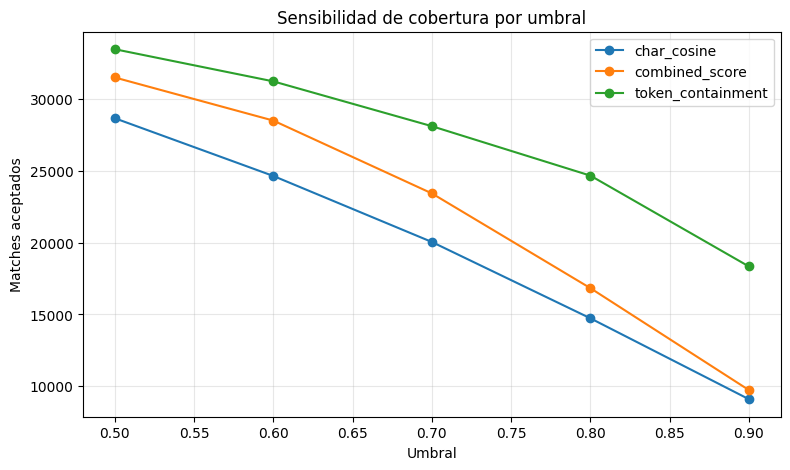

Figura guardada: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/figures/threshold_sensitivity_matches.png


In [11]:
# =========================
# SENSIBILIDAD DE UMBRALES
# =========================

threshold_rows = []
if len(text_alignment_candidates) > 0:
    for metric in ["combined_score", "char_cosine", "token_containment"]:
        for thr in [0.50, 0.60, 0.70, 0.80, 0.90]:
            mask = text_alignment_candidates[metric].ge(thr)
            df_thr = text_alignment_candidates[mask]
            threshold_rows.append({
                "metric_used": metric,
                "threshold": thr,
                "accepted_matches": len(df_thr),
                "audios_covered": df_thr["audio_file"].nunique(),
                "speakers_covered": df_thr[["audio_file", "speaker_final"]].drop_duplicates().shape[0],
                "agent_matches": int((df_thr["official_role"] == "AGENT").sum()),
                "client_matches": int((df_thr["official_role"] == "CLIENT").sum()),
                "mean_combined_score": round(df_thr["combined_score"].mean(), 4) if len(df_thr) else np.nan,
                "mean_char_cosine": round(df_thr["char_cosine"].mean(), 4) if len(df_thr) else np.nan,
                "mean_token_containment": round(df_thr["token_containment"].mean(), 4) if len(df_thr) else np.nan,
            })

threshold_sensitivity = pd.DataFrame(threshold_rows)
display(threshold_sensitivity)

if len(threshold_sensitivity):
    fig, ax = plt.subplots(figsize=(9, 5))
    for metric, df_m in threshold_sensitivity.groupby("metric_used"):
        ax.plot(df_m["threshold"], df_m["accepted_matches"], marker="o", label=metric)
    ax.set_title("Sensibilidad de cobertura por umbral")
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Matches aceptados")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig_path = FIGURES_DIR / "threshold_sensitivity_matches.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", fig_path)

## 7. Matches aceptados y asignación speaker → rol

In [12]:
# =========================
# MATCHES ACEPTADOS DEFAULT
# =========================

if len(text_alignment_candidates) == 0:
    accepted_matches = pd.DataFrame()
else:
    accepted_matches = text_alignment_candidates[text_alignment_candidates["accepted_default"]].copy()
    accepted_matches = accepted_matches.sort_values(["audio_file", "official_turn_idx", "combined_score"], ascending=[True, True, False])

print("Accepted matches:", accepted_matches.shape)
if len(accepted_matches):
    print(accepted_matches["official_role"].value_counts())
    print("Audios cubiertos:", accepted_matches["audio_file"].nunique())
    print("Speakers cubiertos:", accepted_matches[["audio_file", "speaker_final"]].drop_duplicates().shape[0])
    display(accepted_matches[["audio_file", "official_turn_idx", "official_role", "speaker_final", "combined_score", "char_cosine", "token_containment", "similarity_margin", "official_text", "whisper_text"]].head(15))

Accepted matches: (21796, 22)
official_role
AGENT     13561
CLIENT     8235
Name: count, dtype: int64
Audios cubiertos: 1163
Speakers cubiertos: 2286


,audio_file,official_turn_idx,official_role,speaker_final,combined_score,char_cosine,token_containment,similarity_margin,official_text,whisper_text
0,raw_9154117451310006851_clean.wav,0,AGENT,SPEAKER_01,0.940933,0.954000,0.916667,0.830195,"Hola, buenos días, pregunto por Luis Ángel, so...","Hola, buenos días. Pregunto por Luis Ángel. So..."
1,raw_9154117451310006851_clean.wav,1,AGENT,SPEAKER_01,0.911250,0.920141,0.894737,0.620911,"Hola Luis, nada de saludarte, el motivo de mi ...","Hola Luis, me encanta saludarte. El motivo de ..."
2,raw_9154117451310006851_clean.wav,2,AGENT,SPEAKER_01,0.818778,0.721198,1.000000,0.370906,¿Se han llamado los técnicos de plantas?,han llamado los técnicos de plantas terna o al...
4,raw_9154117451310006851_clean.wav,4,AGENT,SPEAKER_00,1.000000,1.000000,1.000000,0.685437,"O sea, ahora tenemos internet.","O sea, ahora tenemos internet."
6,raw_9154117451310006851_clean.wav,6,AGENT,SPEAKER_01,1.000000,1.000000,1.000000,0.391891,Pues es que no nos habían dicho nada.,Pues es que no nos habían dicho nada.
8,raw_9154117451310006851_clean.wav,8,AGENT,SPEAKER_01,0.856337,0.778980,1.000000,0.160281,donde tenías la incidencia.,"Es el tamilloso, ¿no? Donde tenías la incidencia."
10,raw_9154117451310006851_clean.wav,10,CLIENT,SPEAKER_00,0.825180,0.731046,1.000000,0.031973,"Lento, lento, pero bien.","Lento, lento, pero bien. A ver, bien de que ha..."
13,raw_9154117451310006851_clean.wav,13,AGENT,SPEAKER_01,1.000000,1.000000,1.000000,0.356671,"Vale, pues si te parece yo, voy a dejar el seg...","Vale, pues si te parece yo voy a dejar el segu..."
14,raw_9154117451310006851_clean.wav,14,AGENT,SPEAKER_01,0.905340,0.899242,0.916667,0.193589,Porque aquí nos consta como que de momento se ...,Porque aquí nos consta como que de momento se ...
15,raw_9154117451310006851_clean.wav,15,CLIENT,SPEAKER_00,0.811673,0.825651,0.785714,0.558141,"No sé, o sea, ya te digo, Internet ahí, lento,...","Ah, sí. O sea, ya te digo. Internet hay. Lento..."


In [13]:
# =========================
# SPEAKER -> ROLE MAPPING ONE-TO-ONE CON EVIDENCIA TEXTUAL AGREGADA
# =========================

# Corrección principal:
# La versión anterior asignaba roles a partir de matches aceptados aislados.
# Eso era demasiado conservador y dejaba muchos audios sin rol.
# Ahora, para cada audio, se construye una evidencia textual agregada por speaker:
#   - se toman hasta 10 segmentos limpios por hablante;
#   - se priorizan segmentos con bajo overlap, texto no vacío y duración útil;
#   - se juntan esos textos Whisper por SPEAKER_00 / SPEAKER_01;
#   - se comparan contra el texto oficial agregado de AGENT y CLIENT;
#   - se fuerza una asignación one-to-one: un speaker = AGENT y el otro = CLIENT.


def infer_one_to_one_speaker_role_mapping_strict(matches_df):
    """
    Versión estricta anterior, conservada para diagnóstico/holdout.
    No se usa como mapping principal porque depende de matches aislados.
    """
    if matches_df is None or len(matches_df) == 0:
        return pd.DataFrame()

    rows = []
    for audio_file, df_a in matches_df.groupby("audio_file"):
        roles_present = set(df_a["official_role"].dropna().unique())
        if REQUIRE_BOTH_ROLES_PER_AUDIO and not {"AGENT", "CLIENT"}.issubset(roles_present):
            continue

        counts = (
            df_a.groupby(["speaker_final", "official_role"])
            .agg(
                n_matches_role=("official_role", "size"),
                mean_combined_score=("combined_score", "mean"),
                mean_char_cosine=("char_cosine", "mean"),
            )
            .reset_index()
        )
        totals = counts.groupby("speaker_final")["n_matches_role"].sum().reset_index(name="n_matches_total")
        counts = counts.merge(totals, on="speaker_final", how="left")
        counts["role_share"] = counts["n_matches_role"] / counts["n_matches_total"].replace(0, np.nan)

        def best_for_role(role):
            sub = counts[counts["official_role"] == role].copy()
            sub = sub[
                sub["n_matches_role"].ge(MIN_MATCHES_PER_ROLE_IN_AUDIO)
                & sub["n_matches_total"].ge(MIN_MATCHES_FOR_SPEAKER_ROLE)
                & sub["role_share"].ge(MIN_ROLE_PURITY)
            ]
            if len(sub) == 0:
                return None
            sub = sub.sort_values(["role_share", "n_matches_role", "mean_combined_score"], ascending=[False, False, False])
            return sub.iloc[0].to_dict()

        best_agent = best_for_role("AGENT")
        best_client = best_for_role("CLIENT")

        if best_agent is None or best_client is None:
            continue
        if REQUIRE_ONE_TO_ONE_AGENT_CLIENT_MAPPING and best_agent["speaker_final"] == best_client["speaker_final"]:
            continue

        for role, best in [("AGENT", best_agent), ("CLIENT", best_client)]:
            rows.append({
                "audio_file": audio_file,
                "speaker_final": best["speaker_final"],
                "probable_role": role,
                "n_matches_role": int(best["n_matches_role"]),
                "n_matches_total": int(best["n_matches_total"]),
                "role_confidence": float(best["role_share"]),
                "mean_combined_score": float(best["mean_combined_score"]),
                "mean_char_cosine": float(best["mean_char_cosine"]),
                "role_mapping_status": "accepted_speaker_role_strict_matches",
                "role_assignment_method": "strict_accepted_matches_one_to_one",
            })

    return pd.DataFrame(rows)


# Alias para no romper la celda de holdout posterior.
infer_one_to_one_speaker_role_mapping = infer_one_to_one_speaker_role_mapping_strict


def score_text_pair(text_a, text_b):
    """Devuelve score textual entre dos textos con TF-IDF char + overlap léxico."""
    text_a = str(text_a or "").strip()
    text_b = str(text_b or "").strip()
    norm_a = normalize_text_for_match(text_a)
    norm_b = normalize_text_for_match(text_b)

    if count_words(norm_a) == 0 or count_words(norm_b) == 0:
        return {
            "char_cosine": 0.0,
            "token_containment": 0.0,
            "token_jaccard": 0.0,
            "combined_score": 0.0,
        }

    try:
        vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
        X = vectorizer.fit_transform([norm_a, norm_b])
        char_cosine = float(linear_kernel(X[0:1], X[1:2])[0, 0])
    except Exception:
        char_cosine = 0.0

    containment = float(token_containment(norm_a, norm_b))
    jaccard = float(token_jaccard(norm_a, norm_b))
    combined = 0.55 * char_cosine + 0.45 * containment

    return {
        "char_cosine": char_cosine,
        "token_containment": containment,
        "token_jaccard": jaccard,
        "combined_score": float(combined),
    }


def select_role_evidence_segments(df_audio_speaker):
    """
    Selecciona segmentos de evidencia textual para un speaker.
    Prioriza bajo overlap y texto útil, sin exigir que sean anchors acústicos.
    """
    if df_audio_speaker is None or len(df_audio_speaker) == 0:
        return pd.DataFrame()

    df = df_audio_speaker.copy()
    df["whisper_text"] = df.get("whisper_text", "").fillna("").astype(str).str.strip()
    if "whisper_word_count" not in df.columns:
        df["whisper_word_count"] = df["whisper_text"].apply(count_words)

    # Texto útil y segmentos con duración positiva.
    df = df[
        df["whisper_text"].ne("")
        & df["whisper_word_count"].ge(ROLE_EVIDENCE_MIN_WORDS_PER_SEGMENT)
        & pd.to_numeric(df["duration"], errors="coerce").fillna(0).gt(0)
    ].copy()

    if len(df) == 0:
        return df

    # Preferir segmentos OK si existe transcription_status.
    if "transcription_status" in df.columns:
        ok_mask = df["transcription_status"].fillna("").astype(str).str.lower().eq("ok")
        if ok_mask.any():
            df = df[ok_mask].copy()

    # Variables de ordenamiento robustas.
    if "overlap_ratio" not in df.columns:
        df["overlap_ratio"] = 0.0
    if "rms_dbfs" not in df.columns:
        df["rms_dbfs"] = np.nan

    df["overlap_ratio_num"] = pd.to_numeric(df["overlap_ratio"], errors="coerce").fillna(0.0)
    df["duration_num"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0.0)
    df["rms_dbfs_num"] = pd.to_numeric(df["rms_dbfs"], errors="coerce")
    df["low_overlap_preferred"] = df["overlap_ratio_num"].le(ROLE_EVIDENCE_MAX_OVERLAP_RATIO_STRICT)

    # Primero intenta con bajo overlap; si no alcanza evidencia mínima, relaja el criterio.
    strict = df[df["low_overlap_preferred"]].copy()
    strict_seconds = strict["duration_num"].sum()
    strict_words = strict["whisper_word_count"].sum()

    if (
        len(strict) >= ROLE_EVIDENCE_MIN_SEGMENTS_PER_SPEAKER
        and strict_seconds >= ROLE_EVIDENCE_MIN_SECONDS_PER_SPEAKER
        and strict_words >= ROLE_EVIDENCE_MIN_WORDS_PER_SPEAKER
    ):
        pool = strict
    else:
        pool = df

    pool = pool.sort_values(
        ["overlap_ratio_num", "whisper_word_count", "duration_num", "start"],
        ascending=[True, False, False, True]
    ).copy()

    selected_rows = []
    total_seconds = 0.0

    for _, row in pool.iterrows():
        if len(selected_rows) >= ROLE_EVIDENCE_MAX_SEGMENTS_PER_SPEAKER:
            break
        selected_rows.append(row)
        total_seconds += float(row.get("duration_num", 0.0) or 0.0)
        if total_seconds >= ROLE_EVIDENCE_TARGET_SECONDS_PER_SPEAKER:
            break

    return pd.DataFrame(selected_rows)


def build_aggregated_role_evidence(df_whisper_input):
    """Construye una fila de evidencia por audio-speaker."""
    rows = []

    for (audio_file, speaker_final), df_sp in df_whisper_input.groupby(["audio_file", "speaker_final"], dropna=False):
        if pd.isna(speaker_final):
            continue

        selected = select_role_evidence_segments(df_sp)
        if len(selected) == 0:
            continue

        evidence_text = " ".join(selected["whisper_text"].fillna("").astype(str).str.strip()).strip()
        evidence_words = count_words(evidence_text)
        evidence_seconds = float(pd.to_numeric(selected.get("duration", 0), errors="coerce").fillna(0).sum())
        max_overlap = float(pd.to_numeric(selected.get("overlap_ratio", 0), errors="coerce").fillna(0).max()) if "overlap_ratio" in selected.columns else 0.0
        mean_overlap = float(pd.to_numeric(selected.get("overlap_ratio", 0), errors="coerce").fillna(0).mean()) if "overlap_ratio" in selected.columns else 0.0

        status = "sufficient_evidence"
        if len(selected) < ROLE_EVIDENCE_MIN_SEGMENTS_PER_SPEAKER:
            status = "low_segment_count"
        elif evidence_seconds < ROLE_EVIDENCE_MIN_SECONDS_PER_SPEAKER:
            status = "low_duration"
        elif evidence_words < ROLE_EVIDENCE_MIN_WORDS_PER_SPEAKER:
            status = "low_word_count"

        rows.append({
            "audio_file": audio_file,
            "speaker_final": speaker_final,
            "n_evidence_segments": int(len(selected)),
            "speaker_evidence_seconds": evidence_seconds,
            "speaker_evidence_words": int(evidence_words),
            "mean_evidence_overlap_ratio": mean_overlap,
            "max_evidence_overlap_ratio": max_overlap,
            "first_evidence_start": float(pd.to_numeric(selected["start"], errors="coerce").min()) if "start" in selected.columns else np.nan,
            "last_evidence_end": float(pd.to_numeric(selected["end"], errors="coerce").max()) if "end" in selected.columns else np.nan,
            "evidence_status": status,
            "evidence_text": evidence_text,
            "evidence_text_preview": evidence_text[:300],
            "evidence_segment_orders": "|".join(selected.get("segment_order_in_audio", selected.index).astype(str).tolist()),
        })

    return pd.DataFrame(rows)


def infer_aggregated_speaker_role_mapping(df_whisper_input, df_official_turns_input):
    """
    Asigna SPEAKER_00/SPEAKER_01 a AGENT/CLIENT por evidencia textual agregada.
    Devuelve mapping, evidencia y matriz de scores.
    """
    evidence = build_aggregated_role_evidence(df_whisper_input)
    mapping_rows = []
    score_rows = []
    audit_rows = []

    if len(evidence) == 0 or df_official_turns_input is None or len(df_official_turns_input) == 0:
        return pd.DataFrame(), evidence, pd.DataFrame(), pd.DataFrame()

    for audio_file, df_ev_audio in evidence.groupby("audio_file"):
        df_turns_audio = df_official_turns_input[df_official_turns_input["audio_file"] == audio_file].copy()
        roles_present = set(df_turns_audio["official_role"].dropna().unique())

        if REQUIRE_BOTH_ROLES_PER_AUDIO and not {"AGENT", "CLIENT"}.issubset(roles_present):
            audit_rows.append({
                "audio_file": audio_file,
                "aggregate_mapping_status": "missing_both_official_roles",
                "n_speakers_with_evidence": df_ev_audio["speaker_final"].nunique(),
                "roles_present": "|".join(sorted(roles_present)),
            })
            continue

        official_by_role = {}
        for role in ["AGENT", "CLIENT"]:
            text = " ".join(
                df_turns_audio.loc[df_turns_audio["official_role"] == role, "official_text"]
                .fillna("")
                .astype(str)
                .str.strip()
                .tolist()
            ).strip()
            official_by_role[role] = text

        if count_words(official_by_role["AGENT"]) == 0 or count_words(official_by_role["CLIENT"]) == 0:
            audit_rows.append({
                "audio_file": audio_file,
                "aggregate_mapping_status": "empty_official_role_text",
                "n_speakers_with_evidence": df_ev_audio["speaker_final"].nunique(),
                "roles_present": "|".join(sorted(roles_present)),
            })
            continue

        # Usar los dos speakers con más evidencia textual.
        df_ev_audio = df_ev_audio.copy()
        df_ev_audio["speaker_evidence_seconds"] = pd.to_numeric(df_ev_audio["speaker_evidence_seconds"], errors="coerce").fillna(0)
        df_ev_audio["speaker_evidence_words"] = pd.to_numeric(df_ev_audio["speaker_evidence_words"], errors="coerce").fillna(0)
        df_ev_audio = df_ev_audio.sort_values(
            ["speaker_evidence_words", "speaker_evidence_seconds", "n_evidence_segments"],
            ascending=[False, False, False]
        )

        if df_ev_audio["speaker_final"].nunique() < 2:
            audit_rows.append({
                "audio_file": audio_file,
                "aggregate_mapping_status": "less_than_two_speakers_with_evidence",
                "n_speakers_with_evidence": df_ev_audio["speaker_final"].nunique(),
                "roles_present": "|".join(sorted(roles_present)),
            })
            continue

        selected_speakers = df_ev_audio.drop_duplicates("speaker_final").head(2).copy()
        speakers = selected_speakers["speaker_final"].tolist()

        # Score de cada speaker contra cada rol oficial.
        speaker_scores = {}
        for _, ev in selected_speakers.iterrows():
            sp = ev["speaker_final"]
            speaker_scores[sp] = {}
            for role in ["AGENT", "CLIENT"]:
                scores = score_text_pair(ev["evidence_text"], official_by_role[role])
                speaker_scores[sp][role] = scores
                score_rows.append({
                    "audio_file": audio_file,
                    "speaker_final": sp,
                    "official_role": role,
                    "char_cosine": scores["char_cosine"],
                    "token_containment": scores["token_containment"],
                    "token_jaccard": scores["token_jaccard"],
                    "combined_score": scores["combined_score"],
                    "speaker_evidence_seconds": float(ev["speaker_evidence_seconds"]),
                    "speaker_evidence_words": int(ev["speaker_evidence_words"]),
                    "n_evidence_segments": int(ev["n_evidence_segments"]),
                    "evidence_status": ev["evidence_status"],
                })

        sp_a, sp_b = speakers[0], speakers[1]
        combo_1 = speaker_scores[sp_a]["AGENT"]["combined_score"] + speaker_scores[sp_b]["CLIENT"]["combined_score"]
        combo_2 = speaker_scores[sp_a]["CLIENT"]["combined_score"] + speaker_scores[sp_b]["AGENT"]["combined_score"]

        if combo_1 >= combo_2:
            assignment = {sp_a: "AGENT", sp_b: "CLIENT"}
            best_pair_score = combo_1
            second_pair_score = combo_2
        else:
            assignment = {sp_a: "CLIENT", sp_b: "AGENT"}
            best_pair_score = combo_2
            second_pair_score = combo_1

        pair_margin = float(best_pair_score - second_pair_score)

        if best_pair_score < MIN_AGGREGATED_PAIR_SCORE:
            status = "rejected_low_aggregate_score"
        elif pair_margin < MIN_AGGREGATED_PAIR_MARGIN:
            status = "assigned_low_margin_aggregate_text"
        else:
            status = "accepted_speaker_role"

        audit_rows.append({
            "audio_file": audio_file,
            "aggregate_mapping_status": status,
            "n_speakers_with_evidence": df_ev_audio["speaker_final"].nunique(),
            "roles_present": "|".join(sorted(roles_present)),
            "best_pair_score": float(best_pair_score),
            "second_pair_score": float(second_pair_score),
            "pair_score_margin": pair_margin,
            "speaker_a": sp_a,
            "speaker_b": sp_b,
        })

        # No propagar si el score global es demasiado bajo. Los casos de bajo margen sí se conservan
        # como asignación auditable, pero con estado explícito.
        if status == "rejected_low_aggregate_score":
            continue

        for sp, role in assignment.items():
            ev = selected_speakers[selected_speakers["speaker_final"] == sp].iloc[0]
            score_agent = speaker_scores[sp]["AGENT"]["combined_score"]
            score_client = speaker_scores[sp]["CLIENT"]["combined_score"]
            assigned_score = speaker_scores[sp][role]["combined_score"]
            other_role = "CLIENT" if role == "AGENT" else "AGENT"
            other_score = speaker_scores[sp][other_role]["combined_score"]

            mapping_rows.append({
                "audio_file": audio_file,
                "speaker_final": sp,
                "probable_role": role,
                "n_matches_role": np.nan,
                "n_matches_total": int(ev["n_evidence_segments"]),
                "role_confidence": float(max(0.0, assigned_score - other_score)),
                "mean_combined_score": float(assigned_score),
                "mean_char_cosine": float(speaker_scores[sp][role]["char_cosine"]),
                "score_vs_agent": float(score_agent),
                "score_vs_client": float(score_client),
                "assigned_role_score": float(assigned_score),
                "other_role_score": float(other_score),
                "speaker_role_score_margin": float(assigned_score - other_score),
                "best_pair_score": float(best_pair_score),
                "second_pair_score": float(second_pair_score),
                "pair_score_margin": pair_margin,
                "n_evidence_segments": int(ev["n_evidence_segments"]),
                "speaker_evidence_seconds": float(ev["speaker_evidence_seconds"]),
                "speaker_evidence_words": int(ev["speaker_evidence_words"]),
                "mean_evidence_overlap_ratio": float(ev["mean_evidence_overlap_ratio"]),
                "max_evidence_overlap_ratio": float(ev["max_evidence_overlap_ratio"]),
                "first_evidence_start": ev["first_evidence_start"],
                "last_evidence_end": ev["last_evidence_end"],
                "evidence_status": ev["evidence_status"],
                "evidence_text_preview": ev["evidence_text_preview"],
                "role_mapping_status": status,
                "role_assignment_method": "aggregated_speaker_text_one_to_one",
            })

    return (
        pd.DataFrame(mapping_rows),
        evidence,
        pd.DataFrame(score_rows),
        pd.DataFrame(audit_rows),
    )


# Diagnóstico: mapping estricto anterior basado en matches aislados.
speaker_role_mapping_strict_matches = (
    infer_one_to_one_speaker_role_mapping_strict(accepted_matches)
    if len(accepted_matches)
    else pd.DataFrame()
)

# Mapping principal corregido: evidencia textual agregada por speaker.
speaker_role_mapping, speaker_role_evidence_aggregated, speaker_role_score_matrix_aggregated, speaker_role_mapping_audit = infer_aggregated_speaker_role_mapping(
    df_whisper,
    df_official_turns,
)

# Agregar metadata a nivel audio.
if len(speaker_role_mapping):
    meta_cols = [c for c in ["audio_file", "agent_hash", "customer_hash", "brand_ds", "duration_min"] if c in seg_match_audit.columns]
    speaker_role_mapping = speaker_role_mapping.merge(
        seg_match_audit[meta_cols].drop_duplicates("audio_file"),
        on="audio_file",
        how="left"
    )

print("Mapping estricto anterior basado en matches aislados:", speaker_role_mapping_strict_matches.shape)
print("Mapping corregido por evidencia textual agregada:", speaker_role_mapping.shape)

if len(speaker_role_mapping_audit):
    print("\nEstado de asignación por audio:")
    print(speaker_role_mapping_audit["aggregate_mapping_status"].value_counts(dropna=False))

if len(speaker_role_mapping):
    print("\nRoles asignados:")
    print(speaker_role_mapping["probable_role"].value_counts(dropna=False))
    print("Audios con mapping agregado:", speaker_role_mapping["audio_file"].nunique())
    display(speaker_role_mapping.head(20))
else:
    print("No se aceptó ningún mapping speaker→rol mediante evidencia agregada.")

print("\nEvidencia agregada por audio-speaker:", speaker_role_evidence_aggregated.shape)
if len(speaker_role_evidence_aggregated):
    display(speaker_role_evidence_aggregated[[
        "audio_file", "speaker_final", "n_evidence_segments", "speaker_evidence_seconds",
        "speaker_evidence_words", "mean_evidence_overlap_ratio", "evidence_status",
        "evidence_text_preview"
    ]].head(20))


Mapping estricto anterior basado en matches aislados: (1902, 10)
Mapping corregido por evidencia textual agregada: (2332, 31)

Estado de asignación por audio:
aggregate_mapping_status
accepted_speaker_role                   1162
missing_both_official_roles               14
assigned_low_margin_aggregate_text         4
less_than_two_speakers_with_evidence       1
Name: count, dtype: int64

Roles asignados:
probable_role
AGENT     1166
CLIENT    1166
Name: count, dtype: int64
Audios con mapping agregado: 1166


,audio_file,speaker_final,probable_role,n_matches_role,n_matches_total,role_confidence,mean_combined_score,mean_char_cosine,score_vs_agent,score_vs_client,...,first_evidence_start,last_evidence_end,evidence_status,evidence_text_preview,role_mapping_status,role_assignment_method,agent_hash,customer_hash,brand_ds,duration_min
0,raw_9154117451310006851_clean.wav,SPEAKER_01,AGENT,NaN,4,0.472210,0.821495,0.792328,0.821495,0.349284,...,6.426594,137.747844,sufficient_evidence,no hace falta que llames porque está la incide...,accepted_speaker_role,aggregated_speaker_text_one_to_one,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
1,raw_9154117451310006851_clean.wav,SPEAKER_00,CLIENT,NaN,7,0.220715,0.636368,0.575693,0.415653,0.636368,...,5.211594,164.055969,sufficient_evidence,Y yo viajando ahí trabajando el viernes y... V...,accepted_speaker_role,aggregated_speaker_text_one_to_one,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
2,raw_9154117551220006851_clean.wav,SPEAKER_00,AGENT,NaN,3,0.229119,0.546611,0.577310,0.546611,0.317492,...,106.107219,165.760344,sufficient_evidence,"Claro, o la subimos y si quieres yo te lo hago...",accepted_speaker_role,aggregated_speaker_text_one_to_one,022ea603159275cd,73e95b4635bee260,ORANGE,3.29
3,raw_9154117551220006851_clean.wav,SPEAKER_01,CLIENT,NaN,10,0.070341,0.479510,0.492679,0.409169,0.479510,...,17.142219,169.810344,sufficient_evidence,gerente de la empresa y ya voy a llevar todo. ...,accepted_speaker_role,aggregated_speaker_text_one_to_one,022ea603159275cd,73e95b4635bee260,ORANGE,3.29
4,raw_9154152155960016851_clean.wav,SPEAKER_01,AGENT,NaN,4,0.408522,0.730462,0.755386,0.730462,0.321941,...,24.415344,147.113469,sufficient_evidence,"No, nada. Si por probarlo, escucha, habría que...",accepted_speaker_role,aggregated_speaker_text_one_to_one,5c196bda72500462,87ac862422b770da,ORANGE,2.91
5,raw_9154152155960016851_clean.wav,SPEAKER_00,CLIENT,NaN,6,0.267653,0.612457,0.562174,0.344804,0.612457,...,6.105969,161.524719,sufficient_evidence,"Hola Cristina. Buenas tarde. Mira, recogí un p...",accepted_speaker_role,aggregated_speaker_text_one_to_one,5c196bda72500462,87ac862422b770da,ORANGE,2.91
6,raw_9154188548830006851_clean.wav,SPEAKER_01,AGENT,NaN,2,0.528769,0.811982,0.836662,0.811982,0.283214,...,127.757844,159.719094,sufficient_evidence,Gracias por tu tiempo en espera. En este momen...,accepted_speaker_role,aggregated_speaker_text_one_to_one,f746d2b844a92837,23c60e130bae9776,SIMYO,4.51
7,raw_9154188548830006851_clean.wav,SPEAKER_00,CLIENT,NaN,2,0.520081,0.814196,0.779059,0.294116,0.814196,...,60.831594,110.410344,sufficient_evidence,No tiene que haber ninguna línea activa. O sea...,accepted_speaker_role,aggregated_speaker_text_one_to_one,f746d2b844a92837,23c60e130bae9776,SIMYO,4.51
8,raw_9154202560160006851_clean.wav,SPEAKER_01,AGENT,NaN,5,0.544877,0.815500,0.789052,0.815500,0.270623,...,27.469719,96.539094,sufficient_evidence,Yo te puedo ayudar a revisar a ver si lo podem...,accepted_speaker_role,aggregated_speaker_text_one_to_one,d4dcc6490bd514dd,18a87e74b0870b20,ORANGE,2.01
9,raw_9154202560160006851_clean.wav,SPEAKER_00,CLIENT,NaN,4,0.329840,0.670380,0.662510,0.340540,0.670380,...,0.925344,63.649719,sufficient_evidence,Bienvenido a Orange. Mi nombre es Camilo de So...,accepted_speaker_role,aggregated_speaker_text_one_to_one,d4dcc6490bd514dd,18a87e74b0870b20,ORANGE,2.01



Evidencia agregada por audio-speaker: (2361, 13)


,audio_file,speaker_final,n_evidence_segments,speaker_evidence_seconds,speaker_evidence_words,mean_evidence_overlap_ratio,evidence_status,evidence_text_preview
0,raw_9154117451310006851_clean.wav,SPEAKER_00,7,22.646250,68,0.001820,sufficient_evidence,Y yo viajando ahí trabajando el viernes y... V...
1,raw_9154117451310006851_clean.wav,SPEAKER_01,4,29.480625,103,0.000000,sufficient_evidence,no hace falta que llames porque está la incide...
2,raw_9154117551220006851_clean.wav,SPEAKER_00,3,30.915000,106,0.000000,sufficient_evidence,"Claro, o la subimos y si quieres yo te lo hago..."
3,raw_9154117551220006851_clean.wav,SPEAKER_01,10,21.650625,74,0.001667,sufficient_evidence,gerente de la empresa y ya voy a llevar todo. ...
4,raw_9154127337680006851_clean.wav,SPEAKER_00,6,23.085000,57,0.000000,sufficient_evidence,"pasa nada. Vale. Comento, tiene que estar una ..."
5,raw_9154127337680006851_clean.wav,SPEAKER_01,8,25.835625,75,0.000000,sufficient_evidence,"Mañana del 12 a tres. Sí. Vale, pues es que ne..."
6,raw_9154142438160016851_clean.wav,SPEAKER_00,5,22.950000,62,0.000000,sufficient_evidence,"No, yo te digo no, quiero hacerte perder el ti..."
7,raw_9154142438160016851_clean.wav,SPEAKER_01,2,26.915625,91,0.000000,sufficient_evidence,"Bueno, es decir, obviamente, esto es una subve..."
8,raw_9154152155960016851_clean.wav,SPEAKER_00,6,27.168750,89,0.000000,sufficient_evidence,"Hola Cristina. Buenas tarde. Mira, recogí un p..."
9,raw_9154152155960016851_clean.wav,SPEAKER_01,4,27.118125,109,0.000000,sufficient_evidence,"No, nada. Si por probarlo, escucha, habría que..."


In [14]:
# =========================
# PROPAGAR ROL AL DATASET DE SEGMENTOS
# =========================

segment_level_proxy_textual = df_segments.copy()
segment_level_proxy_textual["segment_order_in_audio"] = segment_level_proxy_textual.groupby("audio_file").cumcount()

if len(speaker_role_mapping):
    # Se propagan los mappings agregados aceptados y los de bajo margen, dejando el estado explícito.
    accepted_mapping = speaker_role_mapping[
        speaker_role_mapping["role_mapping_status"].isin([
            "accepted_speaker_role",
            "assigned_low_margin_aggregate_text",
        ])
    ].copy()

    map_cols = [
        "audio_file", "speaker_final", "probable_role", "role_confidence",
        "n_matches_total", "role_mapping_status", "role_assignment_method",
        "score_vs_agent", "score_vs_client", "assigned_role_score", "other_role_score",
        "speaker_role_score_margin", "best_pair_score", "second_pair_score", "pair_score_margin",
        "n_evidence_segments", "speaker_evidence_seconds", "speaker_evidence_words",
        "mean_evidence_overlap_ratio", "max_evidence_overlap_ratio", "evidence_status",
    ]
    map_cols = [c for c in map_cols if c in accepted_mapping.columns]

    segment_level_proxy_textual = segment_level_proxy_textual.merge(
        accepted_mapping[map_cols],
        on=["audio_file", "speaker_final"],
        how="left"
    )
else:
    segment_level_proxy_textual["probable_role"] = pd.NA
    segment_level_proxy_textual["role_confidence"] = np.nan
    segment_level_proxy_textual["n_matches_total"] = np.nan
    segment_level_proxy_textual["role_mapping_status"] = pd.NA
    segment_level_proxy_textual["role_assignment_method"] = pd.NA

segment_level_proxy_textual["official_role_proxy"] = segment_level_proxy_textual["probable_role"]
segment_level_proxy_textual["proxy_method"] = np.where(
    segment_level_proxy_textual["official_role_proxy"].notna(),
    "aggregated_speaker_text_one_to_one",
    "no_textual_proxy"
)
segment_level_proxy_textual["proxy_confidence"] = segment_level_proxy_textual["role_confidence"]

print("Segmentos con proxy textual agregado:", int(segment_level_proxy_textual["official_role_proxy"].notna().sum()))
print("Audios con proxy textual agregado:", segment_level_proxy_textual.loc[segment_level_proxy_textual["official_role_proxy"].notna(), "audio_file"].nunique())
print(segment_level_proxy_textual["proxy_method"].value_counts(dropna=False))

if segment_level_proxy_textual["official_role_proxy"].notna().any():
    print("Distribución de roles propagados:")
    print(segment_level_proxy_textual["official_role_proxy"].value_counts(dropna=False))

cols_preview = [
    "audio_file", "start", "end", "speaker_final", "official_role_proxy",
    "proxy_method", "proxy_confidence", "role_mapping_status",
    "n_evidence_segments", "speaker_evidence_seconds", "speaker_evidence_words",
    "score_vs_agent", "score_vs_client", "pair_score_margin"
]
cols_preview = [c for c in cols_preview if c in segment_level_proxy_textual.columns]
display(segment_level_proxy_textual[cols_preview].head(20))


Segmentos con proxy textual agregado: 39868
Audios con proxy textual agregado: 1166
proxy_method
aggregated_speaker_text_one_to_one    39868
no_textual_proxy                        484
Name: count, dtype: int64
Distribución de roles propagados:
official_role_proxy
AGENT     20672
CLIENT    19196
NaN         484
Name: count, dtype: int64


,audio_file,start,end,speaker_final,official_role_proxy,proxy_method,proxy_confidence,role_mapping_status,n_evidence_segments,speaker_evidence_seconds,speaker_evidence_words,score_vs_agent,score_vs_client,pair_score_margin
0,raw_9154117451310006851_clean.wav,0.030969,4.452219,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925
1,raw_9154117451310006851_clean.wav,5.211594,6.342219,SPEAKER_00,CLIENT,aggregated_speaker_text_one_to_one,0.220715,accepted_speaker_role,7.0,22.646250,68.0,0.415653,0.636368,0.692925
2,raw_9154117451310006851_clean.wav,6.426594,13.800969,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925
3,raw_9154117451310006851_clean.wav,13.800969,14.965344,SPEAKER_00,CLIENT,aggregated_speaker_text_one_to_one,0.220715,accepted_speaker_role,7.0,22.646250,68.0,0.415653,0.636368,0.692925
4,raw_9154117451310006851_clean.wav,15.285969,19.994094,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925
5,raw_9154117451310006851_clean.wav,20.078469,22.187844,SPEAKER_00,CLIENT,aggregated_speaker_text_one_to_one,0.220715,accepted_speaker_role,7.0,22.646250,68.0,0.415653,0.636368,0.692925
6,raw_9154117451310006851_clean.wav,22.727844,23.790969,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925
7,raw_9154117451310006851_clean.wav,25.225344,25.967844,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925
8,raw_9154117451310006851_clean.wav,25.967844,29.899719,SPEAKER_00,CLIENT,aggregated_speaker_text_one_to_one,0.220715,accepted_speaker_role,7.0,22.646250,68.0,0.415653,0.636368,0.692925
9,raw_9154117451310006851_clean.wav,31.300344,33.443469,SPEAKER_01,AGENT,aggregated_speaker_text_one_to_one,0.472210,accepted_speaker_role,4.0,29.480625,103.0,0.821495,0.349284,0.692925


## 8. Evaluación interna tipo train/test dentro de los matches

Para evitar circularidad total, se usa una partición determinística dentro de los matches aceptados: una parte sirve para inferir `speaker → rol` y otra para validar si esa asignación predice el rol oficial de los matches restantes.

In [15]:
# =========================
# EVALUACIÓN HOLDOUT DE MAPPING SPEAKER -> ROLE
# =========================

holdout_metrics_rows = []
holdout_predictions = pd.DataFrame()

if len(accepted_matches) > 0:
    tmp = accepted_matches.copy()
    # Split determinístico: 70% train / 30% test por hash de índice de turno
    tmp["split_key"] = tmp.apply(lambda r: hash(str(r["audio_file"]) + "_" + str(r["official_turn_idx"])) % 10, axis=1)
    train = tmp[tmp["split_key"] < 7].copy()
    test = tmp[tmp["split_key"] >= 7].copy()

    if len(train) and len(test):
        train_map = infer_one_to_one_speaker_role_mapping(train)
        if len(train_map):
            train_map = train_map.rename(columns={
                "probable_role": "predicted_role_from_train",
                "role_confidence": "train_role_confidence"
            })

            holdout_predictions = test.merge(
                train_map[["audio_file", "speaker_final", "predicted_role_from_train", "train_role_confidence", "n_matches_total"]],
                on=["audio_file", "speaker_final"],
                how="left"
            )
            eval_df = holdout_predictions[holdout_predictions["predicted_role_from_train"].notna()].copy()

            if len(eval_df):
                y_true = eval_df["official_role"].astype(str)
                y_pred = eval_df["predicted_role_from_train"].astype(str)
                labels = ["AGENT", "CLIENT"]
                precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
                holdout_metrics_rows.extend([
                    {"metric": "holdout_accuracy", "value": accuracy_score(y_true, y_pred)},
                    {"metric": "holdout_balanced_accuracy", "value": balanced_accuracy_score(y_true, y_pred)},
                    {"metric": "holdout_n_eval_matches", "value": len(eval_df)},
                    {"metric": "holdout_n_audios_eval", "value": eval_df["audio_file"].nunique()},
                ])
                for role, p, r, f, s in zip(labels, precision, recall, f1, support):
                    holdout_metrics_rows.extend([
                        {"metric": f"precision_{role}", "value": p},
                        {"metric": f"recall_{role}", "value": r},
                        {"metric": f"f1_{role}", "value": f},
                        {"metric": f"support_{role}", "value": int(s)},
                    ])

                cm = confusion_matrix(y_true, y_pred, labels=labels)
                cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
                display(cm_df)

holdout_metrics = pd.DataFrame(holdout_metrics_rows)
print("Holdout predictions:", holdout_predictions.shape)
display(holdout_metrics)
if len(holdout_predictions):
    display(holdout_predictions[[c for c in ["audio_file", "official_role", "speaker_final", "predicted_role_from_train", "combined_score", "official_text", "whisper_text"] if c in holdout_predictions.columns]].head(20))


,pred_AGENT,pred_CLIENT
true_AGENT,3175,81
true_CLIENT,63,1983


Holdout predictions: (6508, 26)


,metric,value
0,holdout_accuracy,0.972840
1,holdout_balanced_accuracy,0.972166
2,holdout_n_eval_matches,5302.000000
3,holdout_n_audios_eval,860.000000
4,precision_AGENT,0.980544
5,recall_AGENT,0.975123
6,f1_AGENT,0.977826
7,support_AGENT,3256.000000
8,precision_CLIENT,0.960756
9,recall_CLIENT,0.969208


,audio_file,official_role,speaker_final,predicted_role_from_train,combined_score,official_text,whisper_text
0,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,0.911250,"Hola Luis, nada de saludarte, el motivo de mi ...","Hola Luis, me encanta saludarte. El motivo de ..."
1,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,0.818778,¿Se han llamado los técnicos de plantas?,han llamado los técnicos de plantas terna o al...
2,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,1.000000,"Vale, pues si te parece yo, voy a dejar el seg...","Vale, pues si te parece yo voy a dejar el segu..."
3,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,0.905340,Porque aquí nos consta como que de momento se ...,Porque aquí nos consta como que de momento se ...
4,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,0.863136,"Entonces, vamos a ir llamando estos días para ...",Vale. De acuerdo. Entonces yo lo estoy reclama...
5,raw_9154117451310006851_clean.wav,AGENT,SPEAKER_01,AGENT,1.000000,"Pues ya está, alguna cosita más en la que te p...",Pues ya está. ¿Alguna cosita más en la que te ...
6,raw_9154152155960016851_clean.wav,AGENT,SPEAKER_01,AGENT,0.831021,"Buenas tardes, bienvenido a Orange, mi nombre ...","Buenas tardes, bienvenido a Orange. Mi nombre ..."
7,raw_9154152155960016851_clean.wav,AGENT,SPEAKER_01,AGENT,0.750693,"Pero mira, porque si la compraste directo en u...",Te lo mira porque si la compraste directo en u...
8,raw_9154152155960016851_clean.wav,CLIENT,SPEAKER_00,CLIENT,0.796986,"Sí, António Vargas Fernández.",Sí. ¿Antonio Vargas Hernández?
9,raw_9154152155960016851_clean.wav,AGENT,SPEAKER_01,AGENT,0.881674,Normalmente todas las compras que tú haces en ...,"Mira, este está realizado por la tienda. Norma..."


## 9. Visualizaciones y dashboard exploratorio

,metric,value
0,audios_diarized,1181
1,segments_diarized,40352
2,segments_with_whisper_text,38872
3,audios_with_official_turns_usable_text,1167
4,official_turns_usable_text,37550
5,alignment_candidates,37550
6,accepted_textual_matches_strict,21796
7,audios_with_accepted_textual_matches_strict,1163
8,speakers_with_accepted_textual_matches_strict,2286
9,strict_match_based_speaker_role_mappings,1902


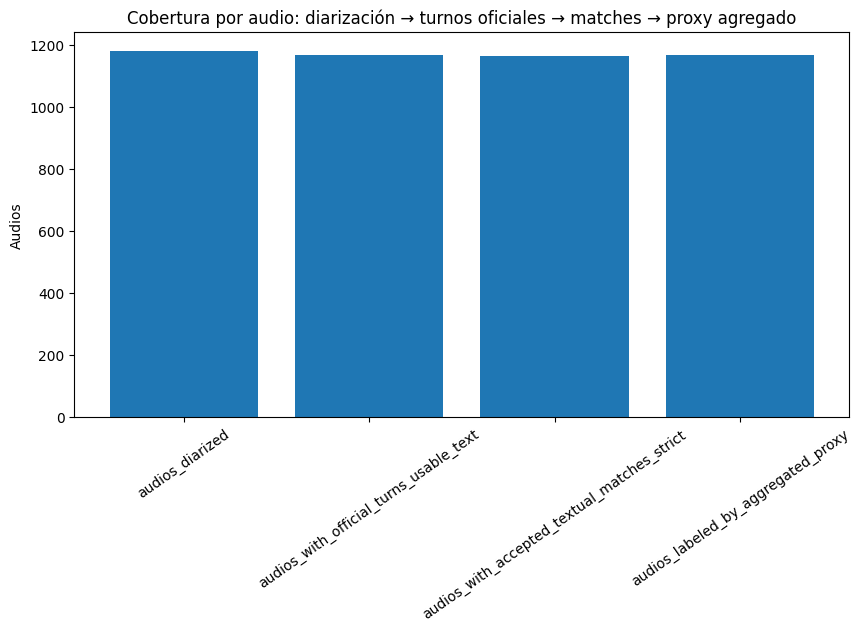

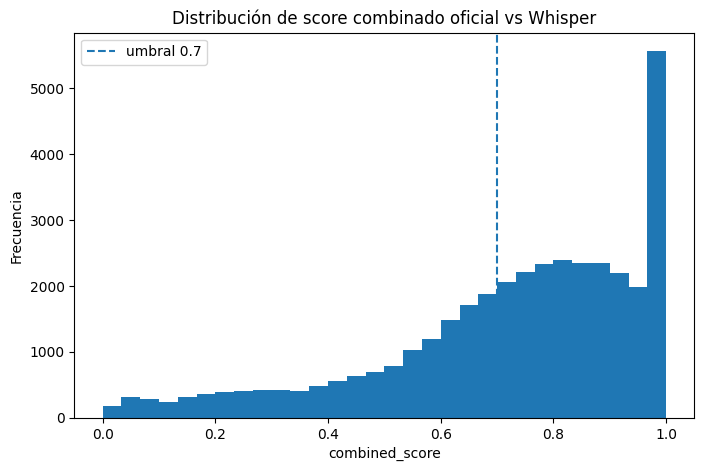

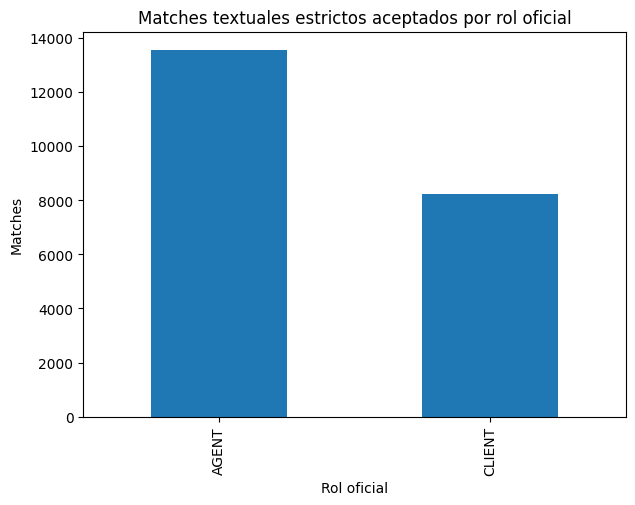

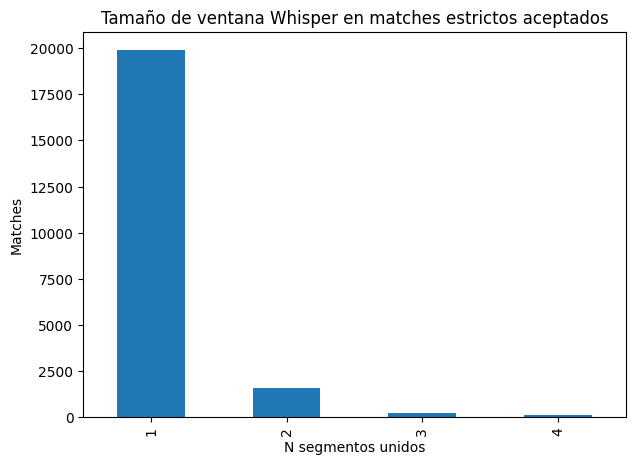

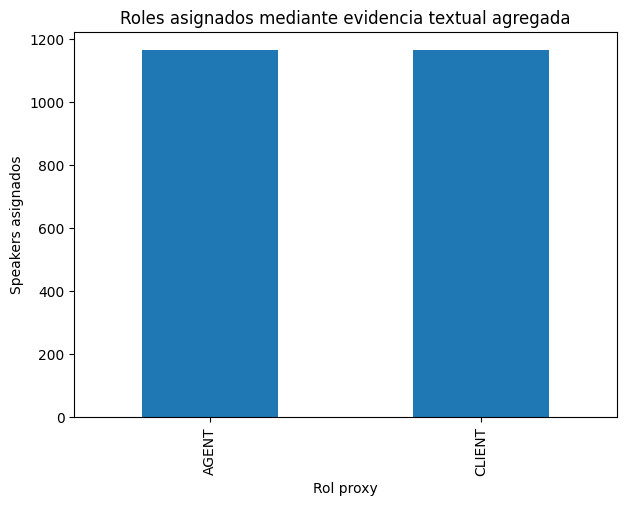

In [16]:
# =========================
# RESUMEN + FIGURAS
# =========================

summary_rows = [
    {"metric": "audios_diarized", "value": int(df_segments["audio_file"].nunique())},
    {"metric": "segments_diarized", "value": int(len(df_segments))},
    {"metric": "segments_with_whisper_text", "value": int(df_whisper["whisper_text"].fillna("").astype(str).str.strip().ne("").sum())},
    {"metric": "audios_with_official_turns_usable_text", "value": int(df_official_turns["audio_file"].nunique())},
    {"metric": "official_turns_usable_text", "value": int(len(df_official_turns))},
    {"metric": "alignment_candidates", "value": int(len(text_alignment_candidates))},
    {"metric": "accepted_textual_matches_strict", "value": int(len(accepted_matches))},
    {"metric": "audios_with_accepted_textual_matches_strict", "value": int(accepted_matches["audio_file"].nunique()) if len(accepted_matches) else 0},
    {"metric": "speakers_with_accepted_textual_matches_strict", "value": int(accepted_matches[["audio_file", "speaker_final"]].drop_duplicates().shape[0]) if len(accepted_matches) else 0},
    {"metric": "strict_match_based_speaker_role_mappings", "value": int(len(speaker_role_mapping_strict_matches)) if "speaker_role_mapping_strict_matches" in globals() and len(speaker_role_mapping_strict_matches) else 0},
    {"metric": "aggregated_speaker_role_mappings", "value": int(len(speaker_role_mapping)) if len(speaker_role_mapping) else 0},
    {"metric": "audios_labeled_by_aggregated_proxy", "value": int(segment_level_proxy_textual.loc[segment_level_proxy_textual["official_role_proxy"].notna(), "audio_file"].nunique())},
    {"metric": "segments_labeled_by_aggregated_proxy", "value": int(segment_level_proxy_textual["official_role_proxy"].notna().sum())},
]
textual_proxy_metrics_summary = pd.DataFrame(summary_rows)

display(textual_proxy_metrics_summary)

# Figura funnel
fig, ax = plt.subplots(figsize=(10, 5))
funnel = textual_proxy_metrics_summary[textual_proxy_metrics_summary["metric"].isin([
    "audios_diarized",
    "audios_with_official_turns_usable_text",
    "audios_with_accepted_textual_matches_strict",
    "audios_labeled_by_aggregated_proxy",
])].copy()
ax.bar(funnel["metric"], funnel["value"])
ax.set_title("Cobertura por audio: diarización → turnos oficiales → matches → proxy agregado")
ax.set_ylabel("Audios")
ax.tick_params(axis="x", rotation=35)
fig_path = FIGURES_DIR / "coverage_funnel_audios.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()

if len(text_alignment_candidates):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(text_alignment_candidates["combined_score"].dropna(), bins=30)
    ax.axvline(ACCEPT_COMBINED_SCORE, linestyle="--", label=f"umbral {ACCEPT_COMBINED_SCORE}")
    ax.set_title("Distribución de score combinado oficial vs Whisper")
    ax.set_xlabel("combined_score")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    fig_path = FIGURES_DIR / "combined_score_distribution.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()

if len(accepted_matches):
    fig, ax = plt.subplots(figsize=(7, 5))
    accepted_matches["official_role"].value_counts().reindex(["AGENT", "CLIENT"]).plot(kind="bar", ax=ax)
    ax.set_title("Matches textuales estrictos aceptados por rol oficial")
    ax.set_xlabel("Rol oficial")
    ax.set_ylabel("Matches")
    fig_path = FIGURES_DIR / "accepted_matches_by_role.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    accepted_matches["window_size"].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title("Tamaño de ventana Whisper en matches estrictos aceptados")
    ax.set_xlabel("N segmentos unidos")
    ax.set_ylabel("Matches")
    fig_path = FIGURES_DIR / "accepted_matches_window_size.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()

if len(speaker_role_mapping):
    fig, ax = plt.subplots(figsize=(7, 5))
    speaker_role_mapping["probable_role"].value_counts().reindex(["AGENT", "CLIENT"]).plot(kind="bar", ax=ax)
    ax.set_title("Roles asignados mediante evidencia textual agregada")
    ax.set_xlabel("Rol proxy")
    ax.set_ylabel("Speakers asignados")
    fig_path = FIGURES_DIR / "aggregated_roles_assigned.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()


In [17]:
# =========================
# DASHBOARD HTML LIGERO
# =========================

def df_to_html_table(df, max_rows=20):
    if df is None or len(df) == 0:
        return "<p>No hay datos.</p>"
    return df.head(max_rows).to_html(index=False, escape=True)

fig_files = sorted(FIGURES_DIR.glob("*.png"))
fig_html = "\n".join([f"<h3>{html.escape(f.stem)}</h3><img src='figures/{html.escape(f.name)}' style='max-width:950px;width:95%;'>" for f in fig_files])

html_content = f"""
<html>
<head>
<meta charset="utf-8">
<title>06B Textual Proxy Ground Truth Dashboard</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 24px; }}
table {{ border-collapse: collapse; margin: 12px 0; }}
th, td {{ border: 1px solid #ddd; padding: 6px 8px; font-size: 12px; }}
th {{ background: #f2f2f2; }}
.metric {{ background: #fafafa; padding: 12px; border-left: 4px solid #888; }}
</style>
</head>
<body>
<h1>06B. Metadata oficial + alineación textual oficial vs Whisper</h1>
<p class="metric">Ground truth proxy mediante evidencia textual agregada por speaker y comparación one-to-one contra los roles oficiales AGENT / CLIENT.</p>
<h2>Resumen de métricas</h2>
{df_to_html_table(textual_proxy_metrics_summary, 50)}
<h2>Sensibilidad de umbrales</h2>
{df_to_html_table(threshold_sensitivity, 50)}
<h2>Métricas holdout</h2>
{df_to_html_table(holdout_metrics, 50)}
<h2>Ejemplos de matches estrictos aceptados</h2>
{df_to_html_table(accepted_matches[[c for c in ["audio_file", "official_role", "speaker_final", "combined_score", "char_cosine", "token_containment", "official_text", "whisper_text"] if c in accepted_matches.columns]], 15) if len(accepted_matches) else "<p>No hay matches aceptados.</p>"}

<h2>Mapping agregado speaker → rol</h2>
{df_to_html_table(speaker_role_mapping[[c for c in ["audio_file", "speaker_final", "probable_role", "role_mapping_status", "role_confidence", "score_vs_agent", "score_vs_client", "speaker_evidence_seconds", "speaker_evidence_words", "evidence_text_preview"] if c in speaker_role_mapping.columns]], 20) if len(speaker_role_mapping) else "<p>No hay mappings agregados.</p>"}

<h2>Figuras</h2>
{fig_html}
</body>
</html>
"""

dashboard_path = OUTPUT_DIR / "06B_textual_proxy_dashboard.html"
dashboard_path.write_text(html_content, encoding="utf-8")
print("Dashboard creado:", dashboard_path)

Dashboard creado: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/06B_textual_proxy_dashboard.html


## 10. Guardar outputs oficiales + subir a GCS

In [18]:
# =========================
# GUARDADO LOCAL + GCS
# =========================

outputs = {}

paths = {
    # Diagnóstico mínimo del antiguo 06B
    "metadata_join_audit_by_audio": OUTPUT_DIR / "metadata_join_audit_by_audio.csv",
    "official_role_presence_by_audio": OUTPUT_DIR / "official_role_presence_by_audio.csv",
    "metadata_role_summary": OUTPUT_DIR / "metadata_role_summary.csv",
    "official_transcription_turns_extracted": OUTPUT_DIR / "official_transcription_turns_extracted.csv",

    # Alineación textual nueva
    "text_alignment_candidates": OUTPUT_DIR / "text_alignment_candidates.csv",
    "text_alignment_matches": OUTPUT_DIR / "text_alignment_matches.csv",
    "text_alignment_threshold_sensitivity": OUTPUT_DIR / "text_alignment_threshold_sensitivity.csv",
    "speaker_role_mapping_textual": OUTPUT_DIR / "speaker_role_mapping_textual.csv",
    "speaker_role_mapping_strict_matches": OUTPUT_DIR / "speaker_role_mapping_strict_matches.csv",
    "speaker_role_evidence_aggregated": OUTPUT_DIR / "speaker_role_evidence_aggregated.csv",
    "speaker_role_score_matrix_aggregated": OUTPUT_DIR / "speaker_role_score_matrix_aggregated.csv",
    "speaker_role_mapping_audit_aggregated": OUTPUT_DIR / "speaker_role_mapping_audit_aggregated.csv",

    # Output principal, con nombre genérico para que sustituya al 06B anterior
    "segment_level_proxy_groundtruth": OUTPUT_DIR / "segment_level_proxy_groundtruth.csv",

    # Métricas y dashboard
    "textual_proxy_metrics_summary": OUTPUT_DIR / "textual_proxy_metrics_summary.csv",
    "alignment_processing_summary": OUTPUT_DIR / "alignment_processing_summary.csv",
    "holdout_role_mapping_predictions": OUTPUT_DIR / "holdout_role_mapping_predictions.csv",
    "holdout_role_mapping_metrics": OUTPUT_DIR / "holdout_role_mapping_metrics.csv",
}

# Diagnóstico / auditoría
seg_match_audit.drop(columns=["transcripcion"], errors="ignore").to_csv(paths["metadata_join_audit_by_audio"], index=False)
outputs["metadata_join_audit_by_audio"] = paths["metadata_join_audit_by_audio"]

if len(role_presence_by_audio):
    role_presence_by_audio.to_csv(paths["official_role_presence_by_audio"], index=False)
    outputs["official_role_presence_by_audio"] = paths["official_role_presence_by_audio"]

metadata_role_summary.to_csv(paths["metadata_role_summary"], index=False)
outputs["metadata_role_summary"] = paths["metadata_role_summary"]

turns_export = df_official_turns.drop(columns=["official_text", "official_norm"], errors="ignore")
turns_export.to_csv(paths["official_transcription_turns_extracted"], index=False)
outputs["official_transcription_turns_extracted"] = paths["official_transcription_turns_extracted"]

# Alineación textual
if len(text_alignment_candidates):
    text_alignment_candidates.to_csv(paths["text_alignment_candidates"], index=False)
    outputs["text_alignment_candidates"] = paths["text_alignment_candidates"]
if len(accepted_matches):
    accepted_matches.to_csv(paths["text_alignment_matches"], index=False)
    outputs["text_alignment_matches"] = paths["text_alignment_matches"]
if len(threshold_sensitivity):
    threshold_sensitivity.to_csv(paths["text_alignment_threshold_sensitivity"], index=False)
    outputs["text_alignment_threshold_sensitivity"] = paths["text_alignment_threshold_sensitivity"]
if "speaker_role_mapping_strict_matches" in globals() and len(speaker_role_mapping_strict_matches):
    speaker_role_mapping_strict_matches.to_csv(paths["speaker_role_mapping_strict_matches"], index=False)
    outputs["speaker_role_mapping_strict_matches"] = paths["speaker_role_mapping_strict_matches"]
if len(speaker_role_mapping):
    speaker_role_mapping.to_csv(paths["speaker_role_mapping_textual"], index=False)
    outputs["speaker_role_mapping_textual"] = paths["speaker_role_mapping_textual"]
if "speaker_role_evidence_aggregated" in globals() and len(speaker_role_evidence_aggregated):
    speaker_role_evidence_aggregated.to_csv(paths["speaker_role_evidence_aggregated"], index=False)
    outputs["speaker_role_evidence_aggregated"] = paths["speaker_role_evidence_aggregated"]
if "speaker_role_score_matrix_aggregated" in globals() and len(speaker_role_score_matrix_aggregated):
    speaker_role_score_matrix_aggregated.to_csv(paths["speaker_role_score_matrix_aggregated"], index=False)
    outputs["speaker_role_score_matrix_aggregated"] = paths["speaker_role_score_matrix_aggregated"]
if "speaker_role_mapping_audit" in globals() and len(speaker_role_mapping_audit):
    speaker_role_mapping_audit.to_csv(paths["speaker_role_mapping_audit_aggregated"], index=False)
    outputs["speaker_role_mapping_audit_aggregated"] = paths["speaker_role_mapping_audit_aggregated"]

# Dataset principal: sin textos largos duplicados
segment_export = segment_level_proxy_textual.drop(columns=["transcripcion", "official_text", "whisper_text", "whisper_norm"], errors="ignore")
segment_export.to_csv(paths["segment_level_proxy_groundtruth"], index=False)
outputs["segment_level_proxy_groundtruth"] = paths["segment_level_proxy_groundtruth"]

textual_proxy_metrics_summary.to_csv(paths["textual_proxy_metrics_summary"], index=False)
outputs["textual_proxy_metrics_summary"] = paths["textual_proxy_metrics_summary"]

alignment_processing_summary.to_csv(paths["alignment_processing_summary"], index=False)
outputs["alignment_processing_summary"] = paths["alignment_processing_summary"]

if len(holdout_predictions):
    holdout_predictions.to_csv(paths["holdout_role_mapping_predictions"], index=False)
    outputs["holdout_role_mapping_predictions"] = paths["holdout_role_mapping_predictions"]
if len(holdout_metrics):
    holdout_metrics.to_csv(paths["holdout_role_mapping_metrics"], index=False)
    outputs["holdout_role_mapping_metrics"] = paths["holdout_role_mapping_metrics"]

outputs["dashboard_html"] = dashboard_path

print("Outputs locales:")
for name, path in outputs.items():
    print(f"- {name}: {path}")

if SAVE_OUTPUTS_TO_GCS:
    print("\nSubiendo outputs principales a GCS...")
    for name, path in outputs.items():
        print(f"- {name}: {upload_file_to_gcs(path)}")
    print("\nSubiendo figuras a GCS...")
    for fig in sorted(FIGURES_DIR.glob("*.png")):
        print(f"- {fig.name}: {upload_file_to_gcs(fig)}")


Outputs locales:
- metadata_join_audit_by_audio: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/metadata_join_audit_by_audio.csv
- official_role_presence_by_audio: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/official_role_presence_by_audio.csv
- metadata_role_summary: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/metadata_role_summary.csv
- official_transcription_turns_extracted: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/official_transcription_turns_extracted.csv
- text_alignment_candidates: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/text_alignment_candidates.csv
- text_alignment_matches: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/text_alignment_matches.csv
- text_alignment_threshold_sensitivity: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/text_alignment_threshold_sensitivity.csv
- speaker_role_mapping_strict_matches: /home/jupy

In [19]:
# =========================
# CONCLUSIÓN AUTOMÁTICA
# =========================

n_segments_total = int(len(df_segments))
n_segments_proxy = int(segment_level_proxy_textual["official_role_proxy"].notna().sum())
n_audios_proxy = int(segment_level_proxy_textual.loc[segment_level_proxy_textual["official_role_proxy"].notna(), "audio_file"].nunique())
n_matches = int(len(accepted_matches))
n_audios_both_roles = int(role_presence_by_audio["has_both_roles"].sum()) if len(role_presence_by_audio) else 0
n_aggregated_mappings = int(len(speaker_role_mapping)) if len(speaker_role_mapping) else 0
n_aggregated_audios = int(speaker_role_mapping["audio_file"].nunique()) if len(speaker_role_mapping) else 0

print("CONCLUSIÓN")
print("=" * 80)
print(f"Segmentos diarizados totales: {n_segments_total}")
print(f"Turnos oficiales con rol reconocido: {len(df_official_turns_all)}")
print(f"Audios con AGENT y CLIENT reconocidos: {n_audios_both_roles}")
print(f"Turnos oficiales usados para proxy textual: {len(df_official_turns)}")
print(f"Matches textuales estrictos aceptados: {n_matches}")
print(f"Mappings speaker→rol por evidencia agregada: {n_aggregated_mappings}")
print(f"Audios con mapping agregado: {n_aggregated_audios}")
print(f"Segmentos con rol proxy propagado: {n_segments_proxy}")
print(f"Audios con algún rol proxy textual: {n_audios_proxy}")
print()
print("Interpretación:")
print("- Este notebook no genera ground truth manual.")
print("- Genera un ground truth proxy textual a partir de transcripciones oficiales con roles AGENT y CLIENT.")
print("- La asignación corregida no depende de un match aislado: agrega varios segmentos Whisper por speaker y los compara contra el texto oficial por rol.")
print("- La asignación speaker→rol exige mapping one-to-one: un speaker AGENT y otro speaker CLIENT.")
print("- Los segmentos heredan el rol asignado a su speaker_final dentro del audio.")
print("- Para métricas supervisadas, reportar siempre que se trata de proxy textual, no referencia manual absoluta.")


CONCLUSIÓN
Segmentos diarizados totales: 40352
Turnos oficiales con rol reconocido: 37747
Audios con AGENT y CLIENT reconocidos: 1167
Turnos oficiales usados para proxy textual: 37550
Matches textuales estrictos aceptados: 21796
Mappings speaker→rol por evidencia agregada: 2332
Audios con mapping agregado: 1166
Segmentos con rol proxy propagado: 39868
Audios con algún rol proxy textual: 1166

Interpretación:
- Este notebook no genera ground truth manual.
- Genera un ground truth proxy textual a partir de transcripciones oficiales con roles AGENT y CLIENT.
- La asignación corregida no depende de un match aislado: agrega varios segmentos Whisper por speaker y los compara contra el texto oficial por rol.
- La asignación speaker→rol exige mapping one-to-one: un speaker AGENT y otro speaker CLIENT.
- Los segmentos heredan el rol asignado a su speaker_final dentro del audio.
- Para métricas supervisadas, reportar siempre que se trata de proxy textual, no referencia manual absoluta.
